In [1]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import regularizers
import xgboost as xgb
from sklearn.decomposition import PCA
from sklearn import tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn import metrics
pd.set_option('display.max_columns',None)
warnings.filterwarnings('ignore')
%matplotlib inline 

# Path to your Kaggle dataset
dataset_path = "/kaggle/input/datasets/mrazaaa/5d-teid-attack-dataset-final/5G_TEID_Attack_Dataset_Clean.csv"

# Load the dataset
data_train = pd.read_csv(dataset_path)

# 1.2 Inspect the dataset
print("Dataset loaded successfully!")
print("Shape of the dataset:", data_train.shape)
print(data_train.head())

2026-04-30 16:58:12.971318: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777568293.187004      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777568293.247125      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777568293.766168      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777568293.766235      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777568293.766238      57 computation_placer.cc:177] computation placer alr

Dataset loaded successfully!
Shape of the dataset: (7939, 72)
   bidirectional_first_seen_ms  bidirectional_duration_ms  \
0                1743690739489                          0   
1                1743690749491                          0   
2                1743690736998                       3980   
3                1743690759491                          0   
4                1743690769492                          0   

   bidirectional_packets  bidirectional_bytes  src2dst_first_seen_ms  \
0                      2                  116          1743690739489   
1                      2                  116          1743690749491   
2                     10                 1420          1743690736998   
3                      2                  116          1743690759491   
4                      2                  116          1743690769492   

   src2dst_last_seen_ms  src2dst_duration_ms  src2dst_packets  src2dst_bytes  \
0         1743690739489                    0              

In [2]:
data_train.head()

,bidirectional_first_seen_ms,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_first_seen_ms,src2dst_last_seen_ms,src2dst_duration_ms,src2dst_packets,src2dst_bytes,dst2src_first_seen_ms,dst2src_last_seen_ms,dst2src_duration_ms,dst2src_packets,dst2src_bytes,bidirectional_min_ps,bidirectional_mean_ps,bidirectional_stddev_ps,bidirectional_max_ps,src2dst_min_ps,src2dst_mean_ps,src2dst_stddev_ps,src2dst_max_ps,dst2src_min_ps,dst2src_mean_ps,dst2src_stddev_ps,dst2src_max_ps,bidirectional_min_piat_ms,bidirectional_mean_piat_ms,bidirectional_stddev_piat_ms,bidirectional_max_piat_ms,src2dst_min_piat_ms,src2dst_mean_piat_ms,src2dst_max_piat_ms,dst2src_min_piat_ms,dst2src_mean_piat_ms,dst2src_stddev_piat_ms,dst2src_max_piat_ms,bidirectional_syn_packets,bidirectional_cwr_packets,bidirectional_ece_packets,bidirectional_urg_packets,bidirectional_ack_packets,bidirectional_psh_packets,bidirectional_rst_packets,bidirectional_fin_packets,src2dst_syn_packets,src2dst_cwr_packets,src2dst_ece_packets,src2dst_urg_packets,src2dst_ack_packets,src2dst_psh_packets,src2dst_rst_packets,src2dst_fin_packets,dst2src_syn_packets,dst2src_cwr_packets,dst2src_ece_packets,dst2src_urg_packets,dst2src_ack_packets,dst2src_psh_packets,dst2src_rst_packets,dst2src_fin_packets,gtp_teid_unique,gtp_teid_switch_rate,gtp_teid_run_len_mean,gtp_teid_packets_mean,gtp_teid_packets_std,gtp_dir_imbalance_teid_mean,gtp_inner_ip_unique,gtp_payload_len_p95,gtp_s_flag_ratio,gtp_error_ind_rate,label
0,1743690739489,0,2,116,1743690739489,1743690739489,0,1,58,1743690739489,1743690739489,0,1,58,58,58.0,0.0,58,58,58.0,0.0,58,58,58.0,0.0,58,0,0.000000,0.000000,0,0,0.0,0,0,0.00,0.00000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,0.002011,1.0,4.5,0.5,0.0,1.0,92.0,0.0,0.0,1
1,1743690749491,0,2,116,1743690749491,1743690749491,0,1,58,1743690749491,1743690749491,0,1,58,58,58.0,0.0,58,58,58.0,0.0,58,58,58.0,0.0,58,0,0.000000,0.000000,0,0,0.0,0,0,0.00,0.00000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,0.002011,1.0,4.5,0.5,0.0,1.0,92.0,0.0,0.0,1
2,1743690736998,3980,10,1420,1743690736998,1743690740978,3980,5,710,1743690736999,1743690740978,3979,5,710,142,142.0,0.0,142,142,142.0,0.0,142,142,142.0,0.0,142,0,442.222222,523.799288,1011,976,995.0,1012,976,994.75,16.52019,1011,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,0.013514,1.0,1.0,0.0,-1.0,0.0,56.0,0.0,0.0,1
3,1743690759491,0,2,116,1743690759491,1743690759491,0,1,58,1743690759491,1743690759491,0,1,58,58,58.0,0.0,58,58,58.0,0.0,58,58,58.0,0.0,58,0,0.000000,0.000000,0,0,0.0,0,0,0.00,0.00000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,0.002011,1.0,4.5,0.5,0.0,1.0,92.0,0.0,0.0,1
4,1743690769492,0,2,116,1743690769492,1743690769492,0,1,58,1743690769492,1743690769492,0,1,58,58,58.0,0.0,58,58,58.0,0.0,58,58,58.0,0.0,58,0,0.000000,0.000000,0,0,0.0,0,0,0.00,0.00000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2.0,0.002011,1.0,4.5,0.5,0.0,1.0,92.0,0.0,0.0,1


label
0    5679
1    2260
Name: count, dtype: int64
Class Distribution (Traffic Type):
label
0    5679
1    2260
Name: count, dtype: int64


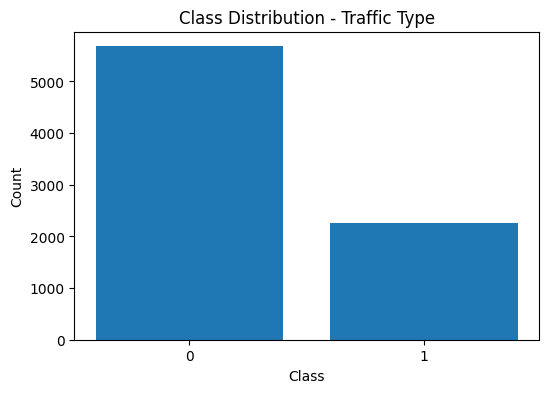

In [5]:
label = data_train['label']  

print(data_train['label'].value_counts())

value_counts = label.value_counts()
print("Class Distribution (Traffic Type):")
print(value_counts)

labels = ["0", "1"]  
plt.figure(figsize=(6,4))
plt.bar(labels, value_counts)
plt.title("Class Distribution - Traffic Type")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [6]:
print("\nDataset info:")
data_train.info()



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7939 entries, 0 to 7938
Data columns (total 72 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bidirectional_first_seen_ms   7939 non-null   int64  
 1   bidirectional_duration_ms     7939 non-null   int64  
 2   bidirectional_packets         7939 non-null   int64  
 3   bidirectional_bytes           7939 non-null   int64  
 4   src2dst_first_seen_ms         7939 non-null   int64  
 5   src2dst_last_seen_ms          7939 non-null   int64  
 6   src2dst_duration_ms           7939 non-null   int64  
 7   src2dst_packets               7939 non-null   int64  
 8   src2dst_bytes                 7939 non-null   int64  
 9   dst2src_first_seen_ms         7939 non-null   int64  
 10  dst2src_last_seen_ms          7939 non-null   int64  
 11  dst2src_duration_ms           7939 non-null   int64  
 12  dst2src_packets               7939 non-null   i

In [7]:
missing_values =data_train.isnull().sum()
print("\nMissing values in each column:\n", missing_values)


Missing values in each column:
 bidirectional_first_seen_ms    0
bidirectional_duration_ms      0
bidirectional_packets          0
bidirectional_bytes            0
src2dst_first_seen_ms          0
                              ..
gtp_inner_ip_unique            0
gtp_payload_len_p95            0
gtp_s_flag_ratio               0
gtp_error_ind_rate             0
label                          0
Length: 72, dtype: int64


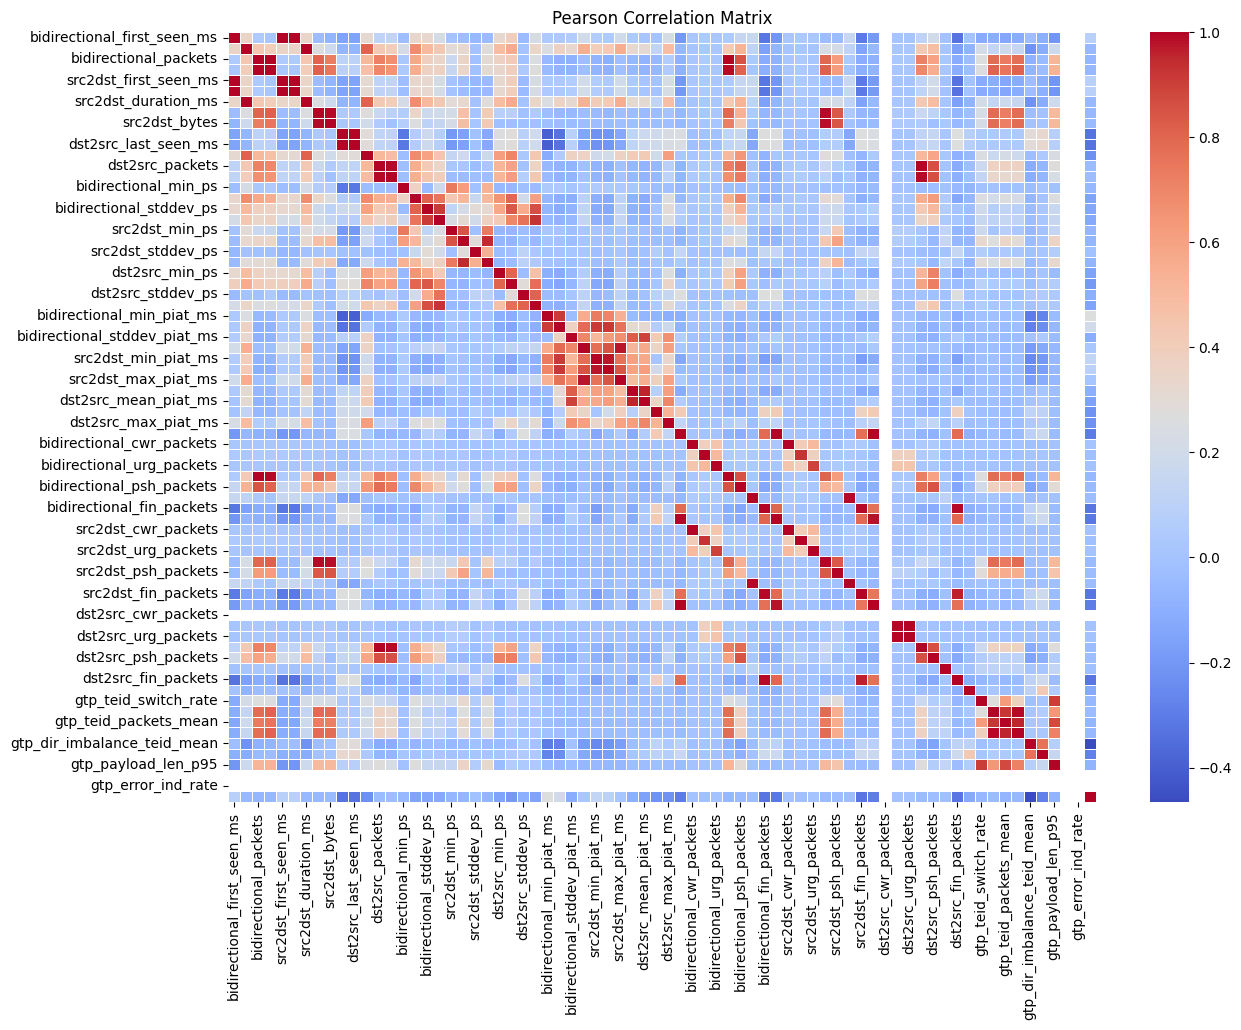

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = data_train.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Matrix")
plt.show()

HIGHLY CORRELATED FEATURE PAIRS (above 0.9):
dst2src_last_seen_ms <-> dst2src_first_seen_ms: 1.0000
dst2src_first_seen_ms <-> dst2src_last_seen_ms: 1.0000
src2dst_first_seen_ms <-> src2dst_last_seen_ms: 1.0000
src2dst_last_seen_ms <-> bidirectional_first_seen_ms: 1.0000
bidirectional_first_seen_ms <-> src2dst_last_seen_ms: 1.0000
src2dst_last_seen_ms <-> src2dst_first_seen_ms: 1.0000
dst2src_ack_packets <-> dst2src_packets: 1.0000
dst2src_packets <-> dst2src_ack_packets: 1.0000
bidirectional_duration_ms <-> src2dst_duration_ms: 0.9987
src2dst_duration_ms <-> bidirectional_duration_ms: 0.9987
bidirectional_packets <-> bidirectional_ack_packets: 0.9966
bidirectional_ack_packets <-> bidirectional_packets: 0.9966
dst2src_syn_packets <-> bidirectional_syn_packets: 0.9956
bidirectional_syn_packets <-> dst2src_syn_packets: 0.9956
bidirectional_syn_packets <-> src2dst_syn_packets: 0.9952
src2dst_syn_packets <-> bidirectional_syn_packets: 0.9952
bidirectional_packets <-> bidirectional_bytes: 0.

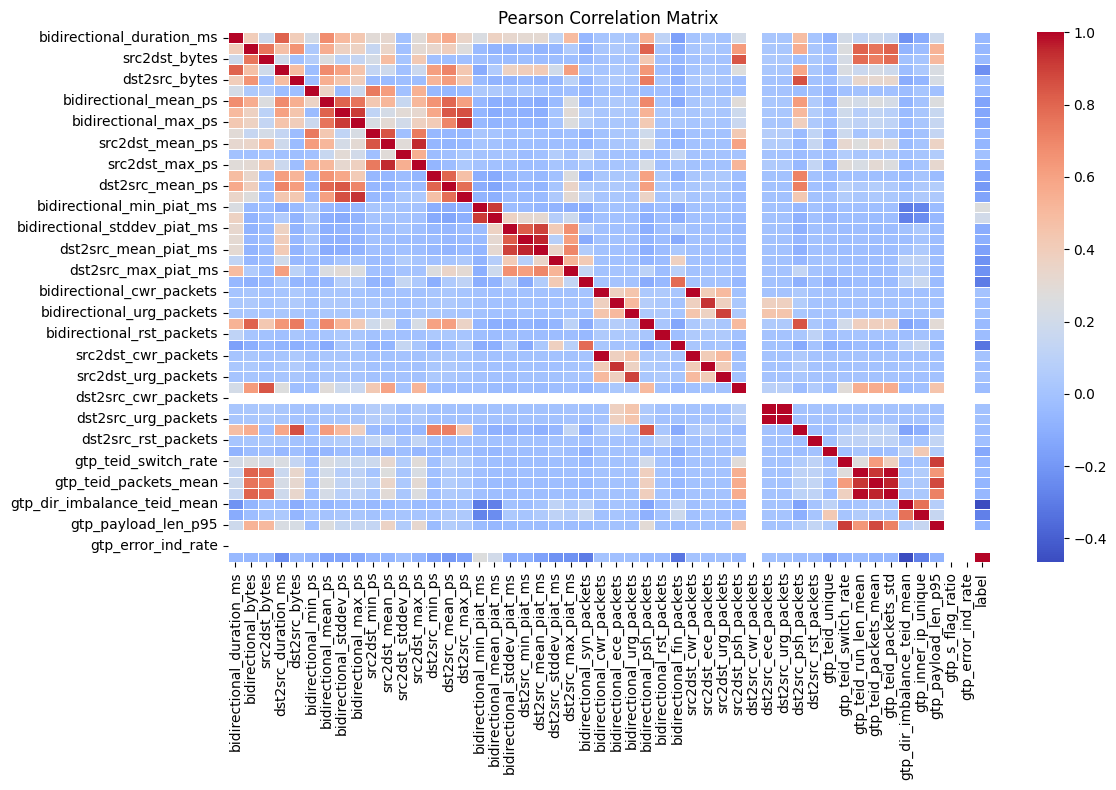

Original dataset shape: (7939, 72)
Reduced dataset shape: (7939, 50)
Number of features dropped: 22


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

correlation_threshold = 0.9


high_corr_pairs = correlation_matrix.unstack().sort_values(ascending=False)
high_corr_pairs = high_corr_pairs[high_corr_pairs != 1.0]  # Exclude self-correlation
high_corr_pairs = high_corr_pairs[abs(high_corr_pairs) > correlation_threshold]

print("HIGHLY CORRELATED FEATURE PAIRS (above 0.9):")
print("=" * 50)
for pair, corr_value in high_corr_pairs.items():
    feature1, feature2 = pair
    print(f"{feature1} <-> {feature2}: {corr_value:.4f}")

print(f"\nTotal highly correlated pairs found: {len(high_corr_pairs)}")


print("\n" + "=" * 50)
print("FEATURE CORRELATION FREQUENCY ANALYSIS:")
print("=" * 50)

feature_corr_count = {}
for pair, corr_value in high_corr_pairs.items():
    feature1, feature2 = pair
    feature_corr_count[feature1] = feature_corr_count.get(feature1, 0) + 1
    feature_corr_count[feature2] = feature_corr_count.get(feature2, 0) + 1


sorted_features = sorted(feature_corr_count.items(), key=lambda x: x[1], reverse=True)

print("\nFeatures with most high correlations (potential candidates for removal):")
for feature, count in sorted_features:
    print(f"  {feature}: appears in {count} highly correlated pairs")

features_to_drop = [

    'src2dst_last_seen_ms', 'bidirectional_first_seen_ms', 
    'src2dst_first_seen_ms', 'dst2src_last_seen_ms', 'dst2src_first_seen_ms',
    
   
    'dst2src_packets', 'src2dst_packets', 'bidirectional_packets',
    'dst2src_ack_packets', 'src2dst_ack_packets', 'bidirectional_ack_packets',
    
    
    'src2dst_duration_ms',
    
    
    'src2dst_syn_packets', 'dst2src_syn_packets',
    'src2dst_fin_packets', 'dst2src_fin_packets',
    
  
    'src2dst_max_piat_ms', 'src2dst_mean_piat_ms', 'src2dst_min_piat_ms',
    'bidirectional_max_piat_ms',
    
    
    'src2dst_rst_packets',  
    'dst2src_stddev_ps',    
]


final_drop_list = [f for f in features_to_drop if f in data_train.columns]
print(f"\nDropping {len(final_drop_list)} NFStream features")


data_reduced = data_train.drop(columns=final_drop_list)


import seaborn as sns
import matplotlib.pyplot as plt


correlation_matrix_reduced = data_reduced.corr()

# Plot heatmap for reduced features
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix_reduced, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()


print(f"Original dataset shape: {data_train.shape}")
print(f"Reduced dataset shape: {data_reduced.shape}")
print(f"Number of features dropped: {len(final_drop_list)}")

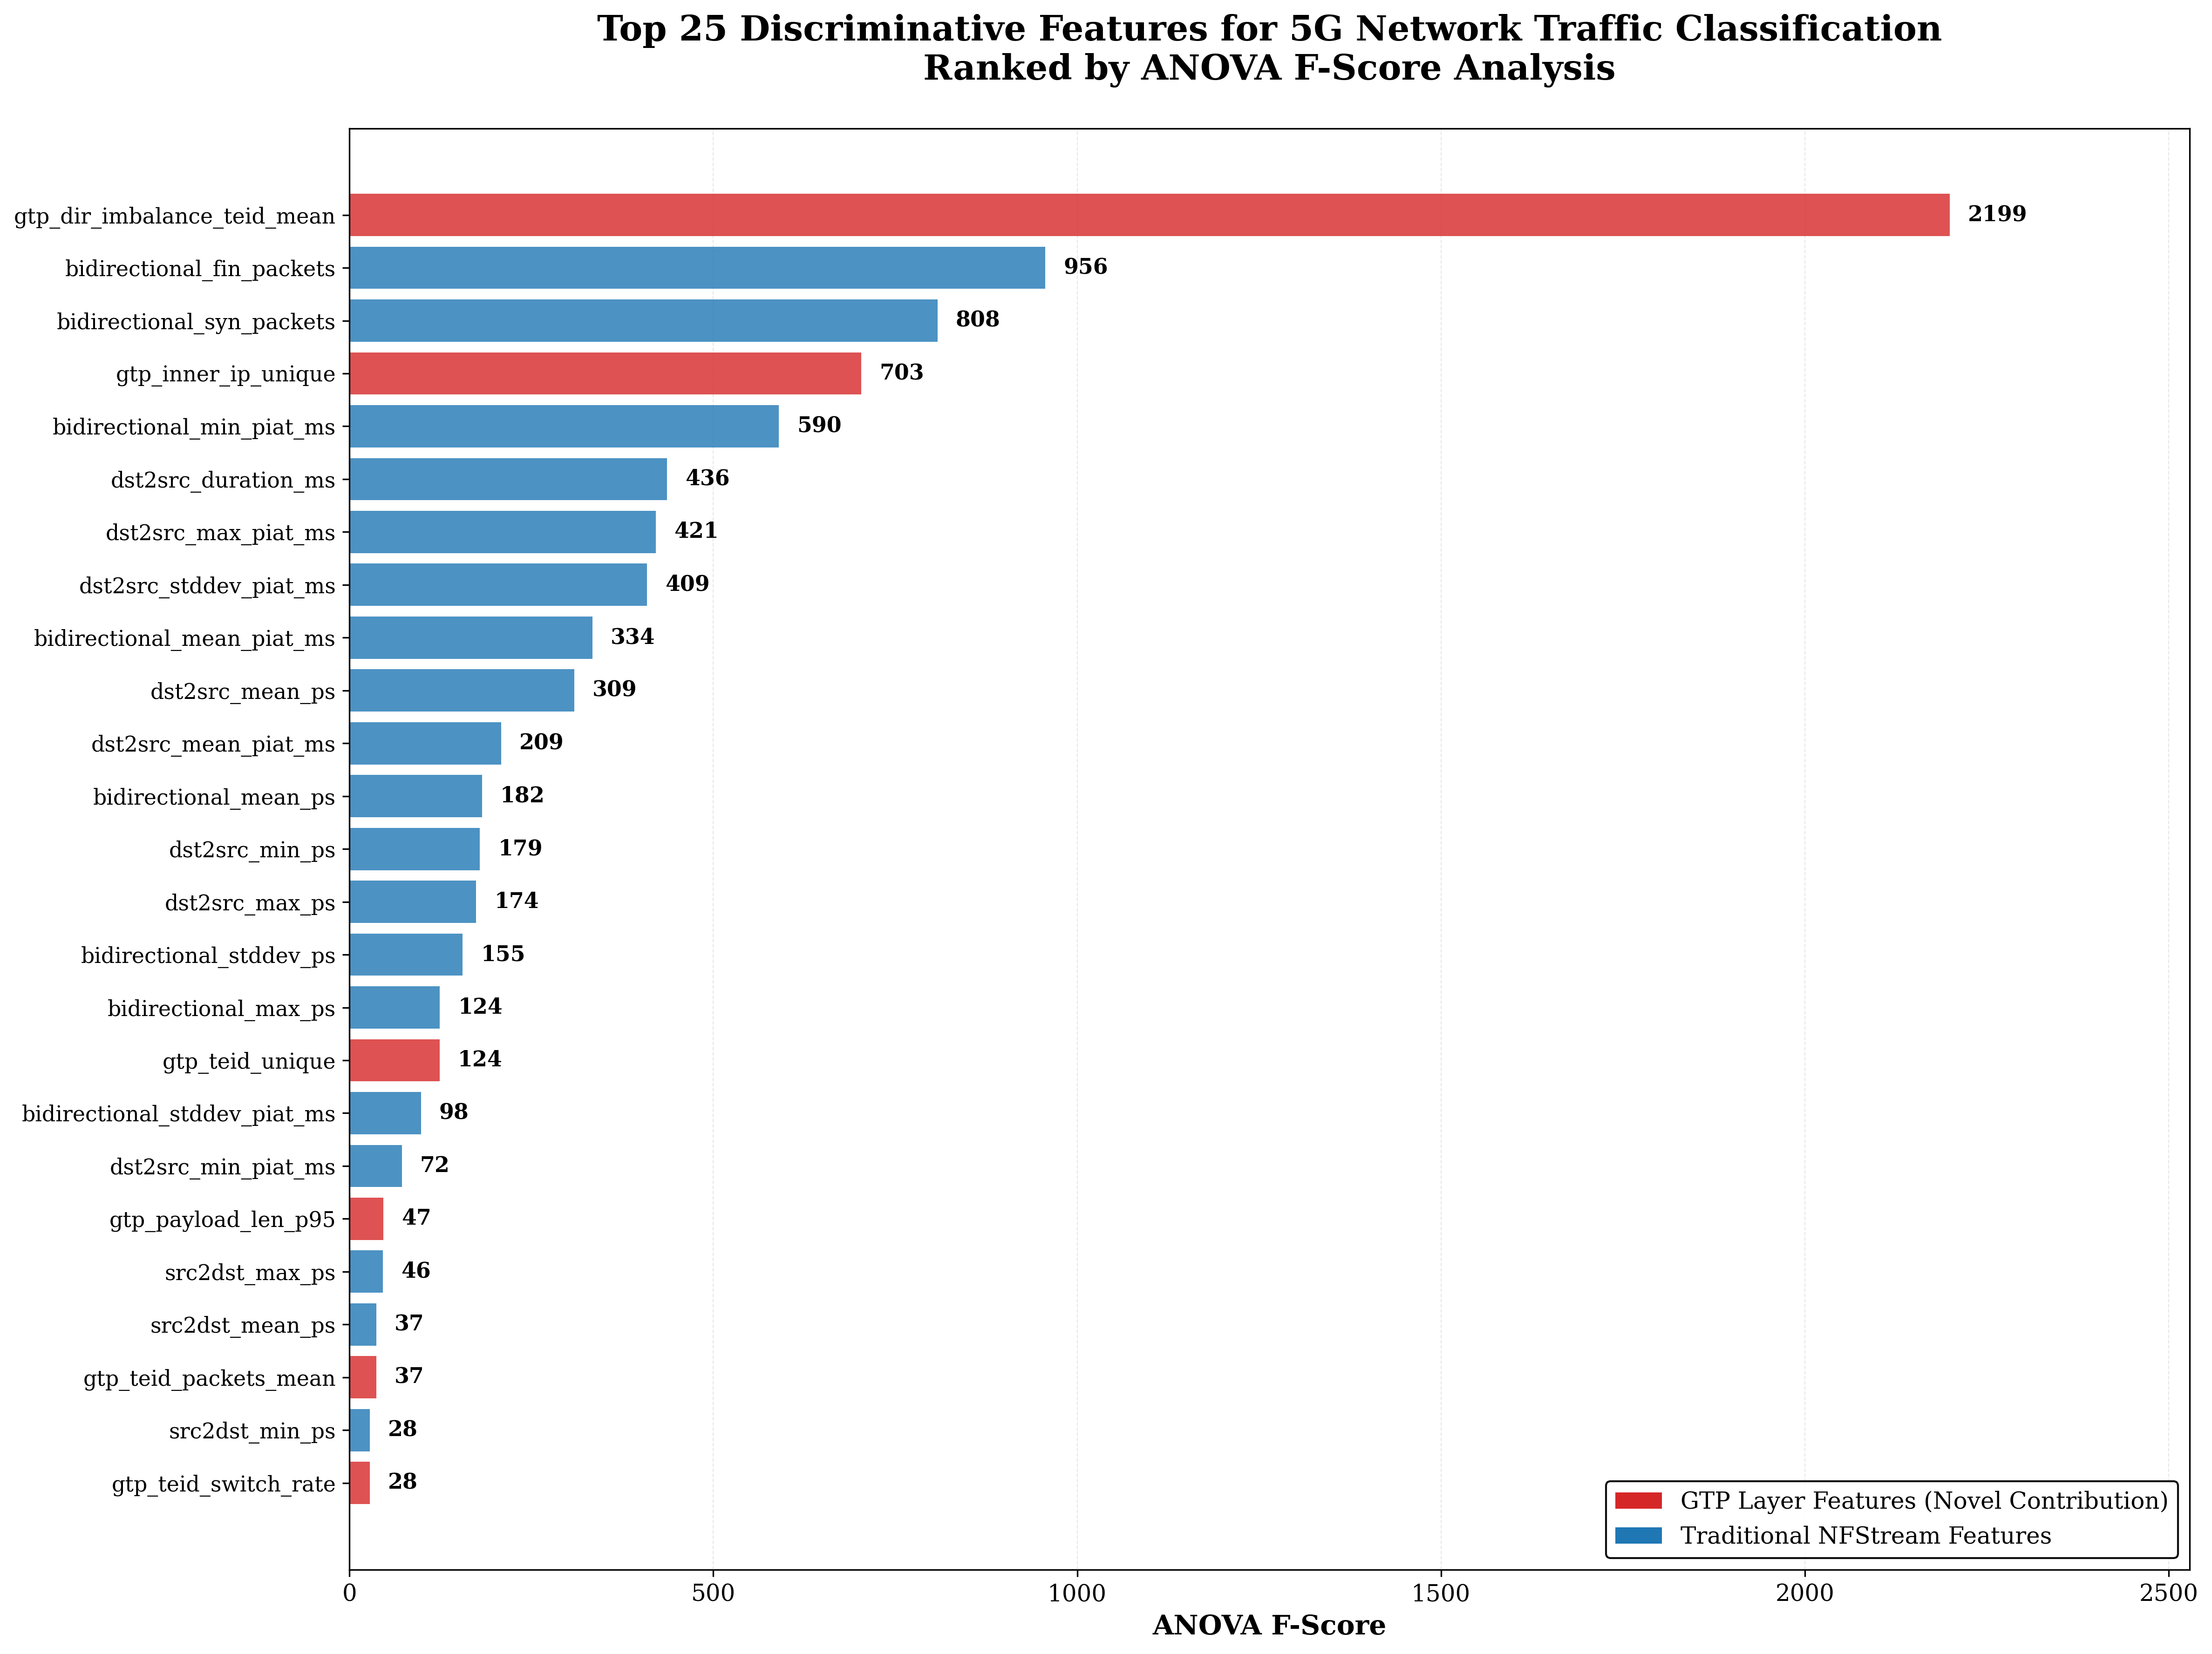

TABLE 1: Top 25 Features by ANOVA F-Score for 5G Traffic Classification
Rank Feature                                  F-Score      p-Value         Type        
----------------------------------------------------------------------------------------------------
1    gtp_dir_imbalance_teid_mean              2198.9       0.00e+00        GTP         
2    bidirectional_fin_packets                956.4        2.24e-198       NFStream    
3    bidirectional_syn_packets                808.0        2.41e-169       NFStream    
4    gtp_inner_ip_unique                      703.3        1.47e-148       GTP         
5    bidirectional_min_piat_ms                590.2        8.11e-126       NFStream    
6    dst2src_duration_ms                      436.2        2.41e-94        NFStream    
7    dst2src_max_piat_ms                      421.3        2.92e-91        NFStream    
8    dst2src_stddev_piat_ms                   409.1        9.51e-89        NFStream    
9    bidirectional_mean_piat_ms    

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'serif'
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300


fig, ax = plt.subplots(1, 1, figsize=(16, 12))


top_25_f_scores = f_scores.head(25).copy()
colors = ['#D62728' if 'gtp' in f.lower() else '#1F77B4' for f in top_25_f_scores['feature']]


y_pos = np.arange(len(top_25_f_scores))
bars = ax.barh(y_pos, top_25_f_scores['f_score'], color=colors, alpha=0.8, height=0.8)


ax.set_yticks(y_pos)
ax.set_yticklabels(top_25_f_scores['feature'])
ax.invert_yaxis()  # Highest F-score at the top

ax.set_xlabel('ANOVA F-Score', fontsize=14, fontweight='bold')
ax.set_xlim(0, top_25_f_scores['f_score'].max() * 1.15)  # Add space for labels


for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 25, bar.get_y() + bar.get_height()/2, 
             f'{width:.0f}', ha='left', va='center', 
             fontweight='bold', fontsize=11)

# Add grid for better readability
ax.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)  # Grid behind bars

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D62728', label='GTP Layer Features (Novel Contribution)'),
    Patch(facecolor='#1F77B4', label='Traditional NFStream Features')
]
ax.legend(handles=legend_elements, loc='lower right', framealpha=0.95, 
          fontsize=12, frameon=True, edgecolor='black')


ax.set_title('Top 25 Discriminative Features for 5G Network Traffic Classification\n'
             'Ranked by ANOVA F-Score Analysis', 
             fontsize=18, fontweight='bold', pad=25)


ax.tick_params(axis='y', which='major', labelsize=11)
ax.tick_params(axis='x', which='major', labelsize=12)

plt.tight_layout()


plt.savefig('ANOVA_Feature_Importance_5G_Traffic.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()


print("TABLE 1: Top 25 Features by ANOVA F-Score for 5G Traffic Classification")
print("="*100)
print(f"{'Rank':<4} {'Feature':<40} {'F-Score':<12} {'p-Value':<15} {'Type':<12}")
print("-"*100)
for i, (_, row) in enumerate(f_scores.head(25).iterrows(), 1):
    p_val_str = f"{row['p_value']:.2e}"
    feature_type = "GTP" if 'gtp' in row['feature'].lower() else "NFStream"
    print(f"{i:<4} {row['feature']:<40} {row['f_score']:<12.1f} {p_val_str:<15} {feature_type:<12}")




ANALYZING MODEL: Logistic Regression

>>> Mode: WITHOUT plugin
              precision    recall  f1-score   support

           0      0.769     0.965     0.856      5679
           1      0.755     0.273     0.401      2260

    accuracy                          0.768      7939
   macro avg      0.762     0.619     0.629      7939
weighted avg      0.765     0.768     0.727      7939



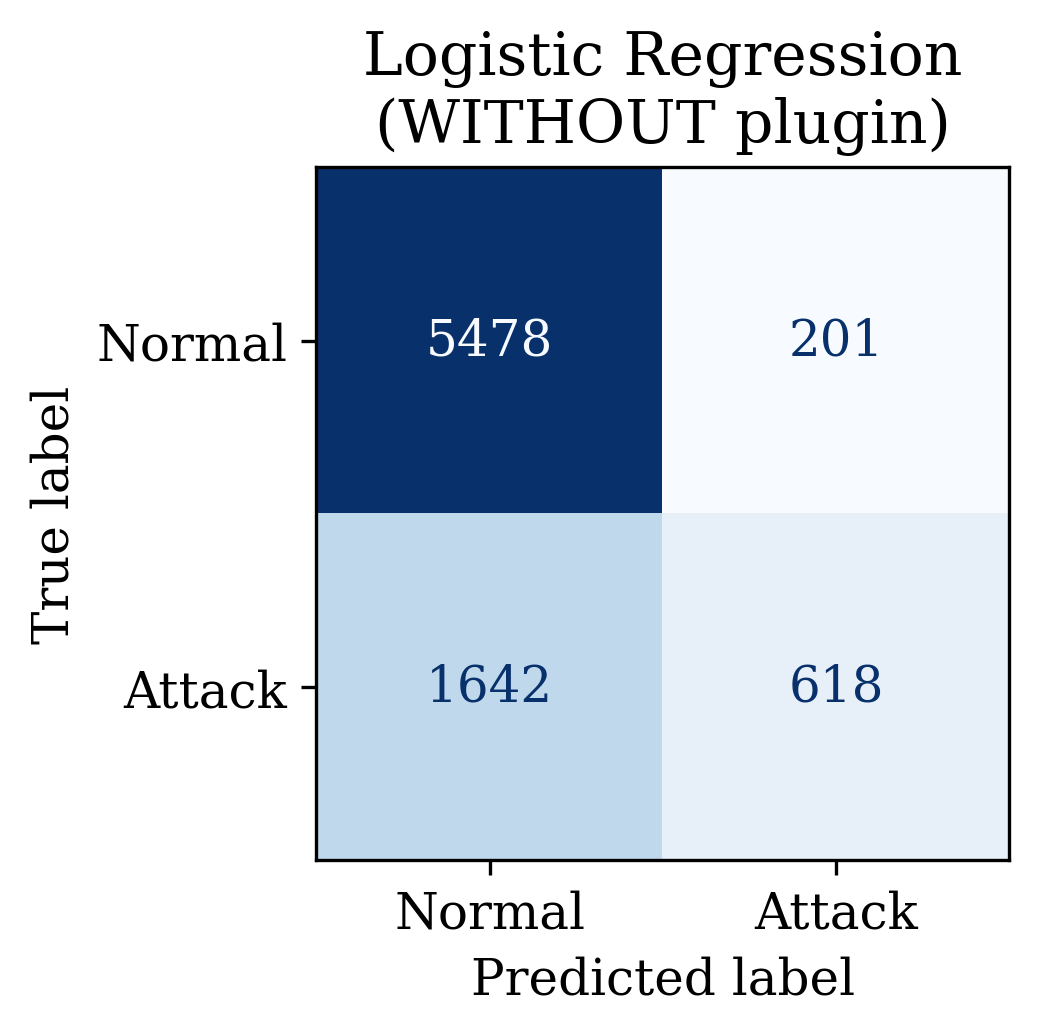


>>> Mode: WITH plugin
              precision    recall  f1-score   support

           0      0.985     0.958     0.971      5679
           1      0.901     0.964     0.931      2260

    accuracy                          0.960      7939
   macro avg      0.943     0.961     0.951      7939
weighted avg      0.961     0.960     0.960      7939



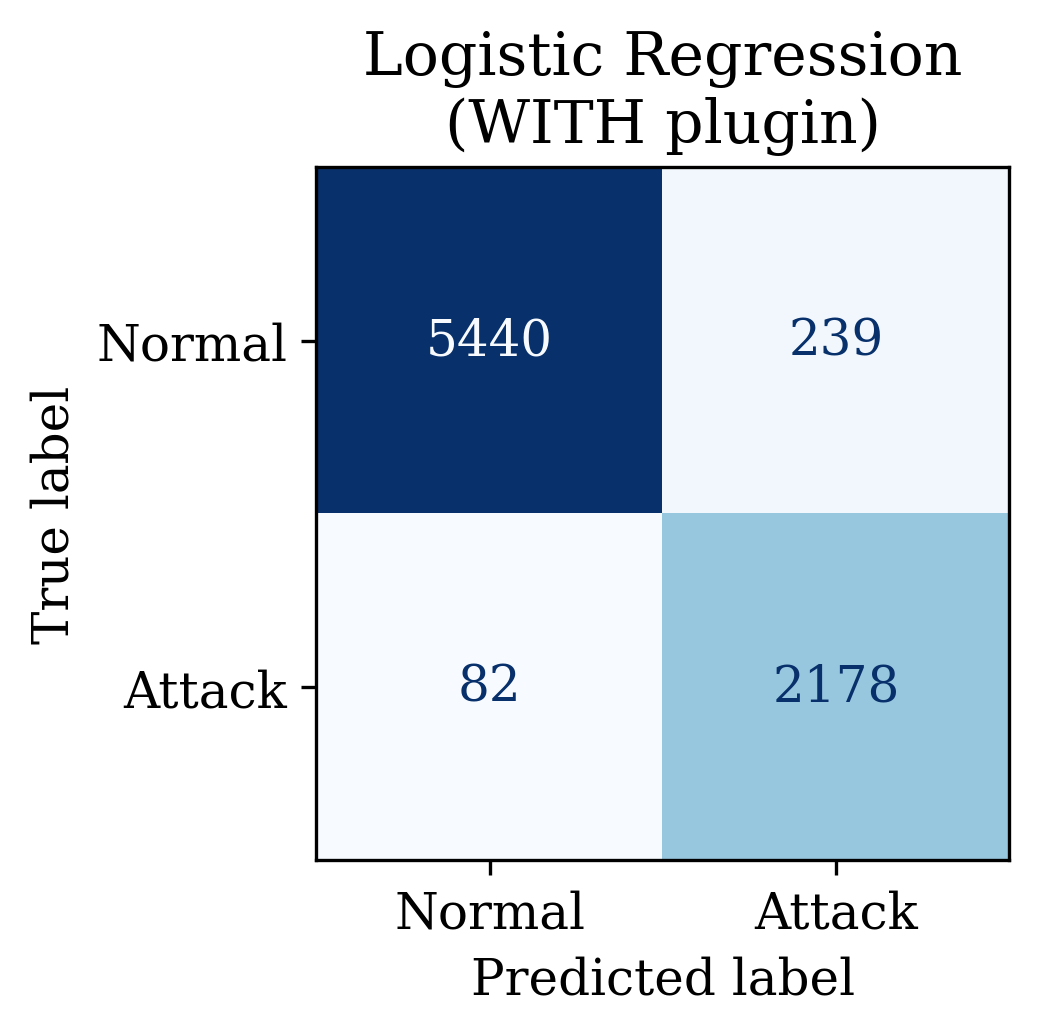


ANALYZING MODEL: K-Nearest Neighbours

>>> Mode: WITHOUT plugin
              precision    recall  f1-score   support

           0      0.886     0.868     0.877      5679
           1      0.685     0.718     0.701      2260

    accuracy                          0.826      7939
   macro avg      0.785     0.793     0.789      7939
weighted avg      0.828     0.826     0.827      7939



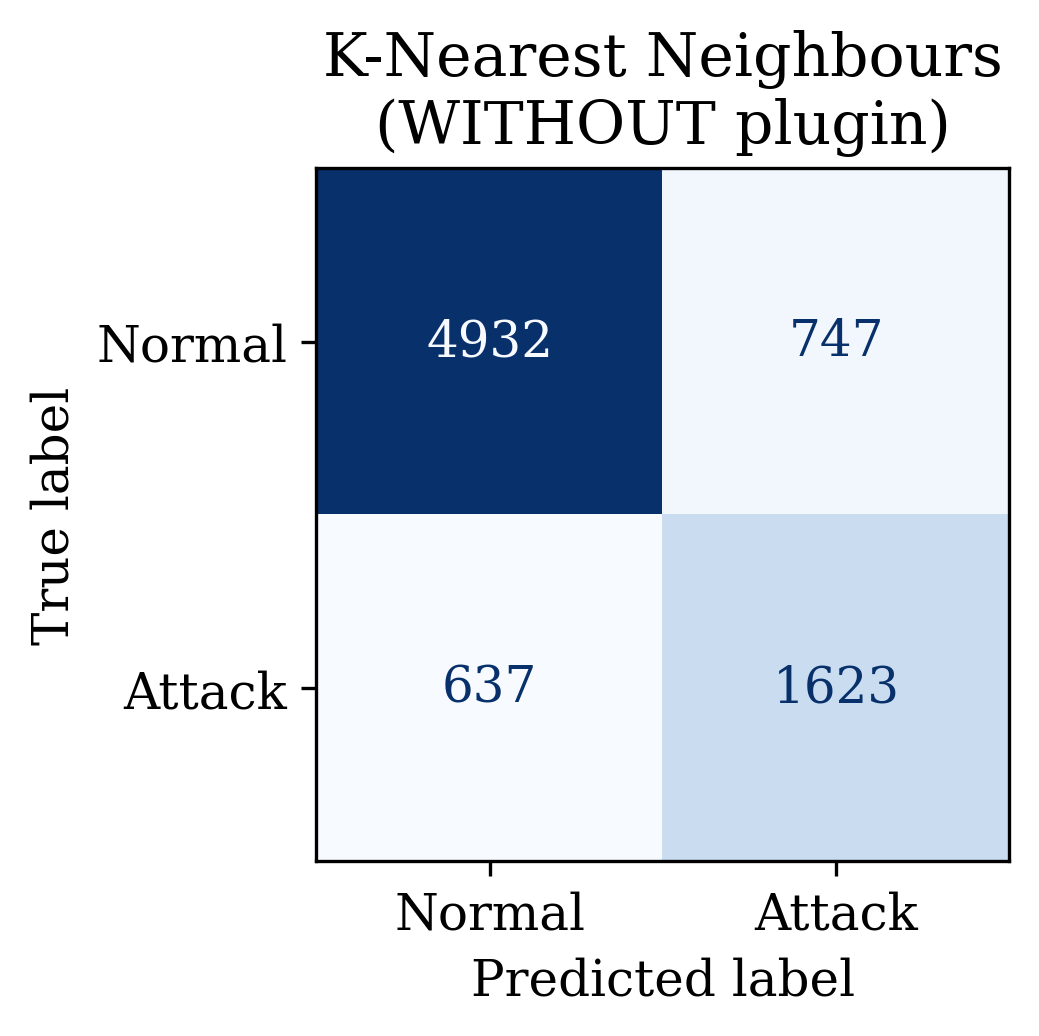


>>> Mode: WITH plugin
              precision    recall  f1-score   support

           0      0.995     0.993     0.994      5679
           1      0.983     0.988     0.986      2260

    accuracy                          0.992      7939
   macro avg      0.989     0.991     0.990      7939
weighted avg      0.992     0.992     0.992      7939



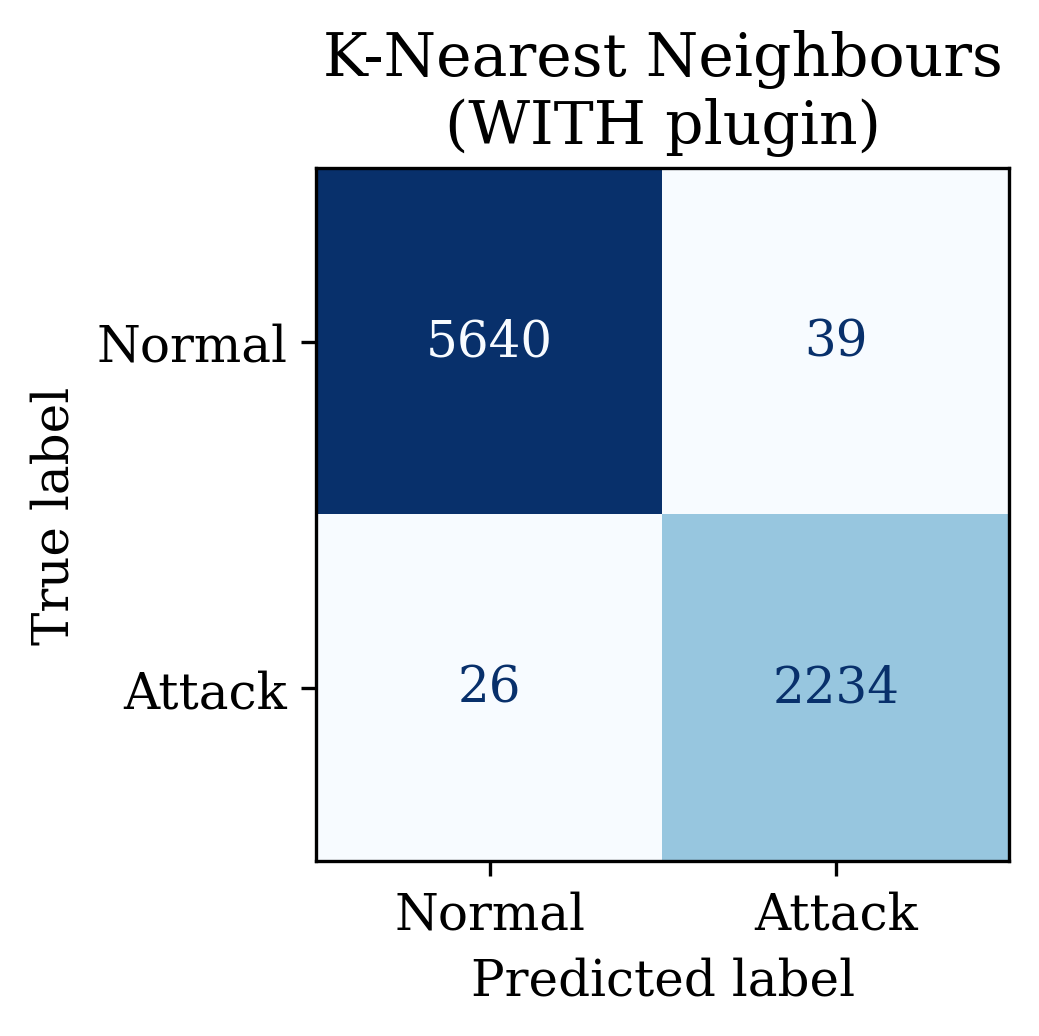


ANALYZING MODEL: SVM

>>> Mode: WITHOUT plugin
              precision    recall  f1-score   support

           0      0.769     0.990     0.865      5679
           1      0.907     0.252     0.394      2260

    accuracy                          0.780      7939
   macro avg      0.838     0.621     0.630      7939
weighted avg      0.808     0.780     0.731      7939



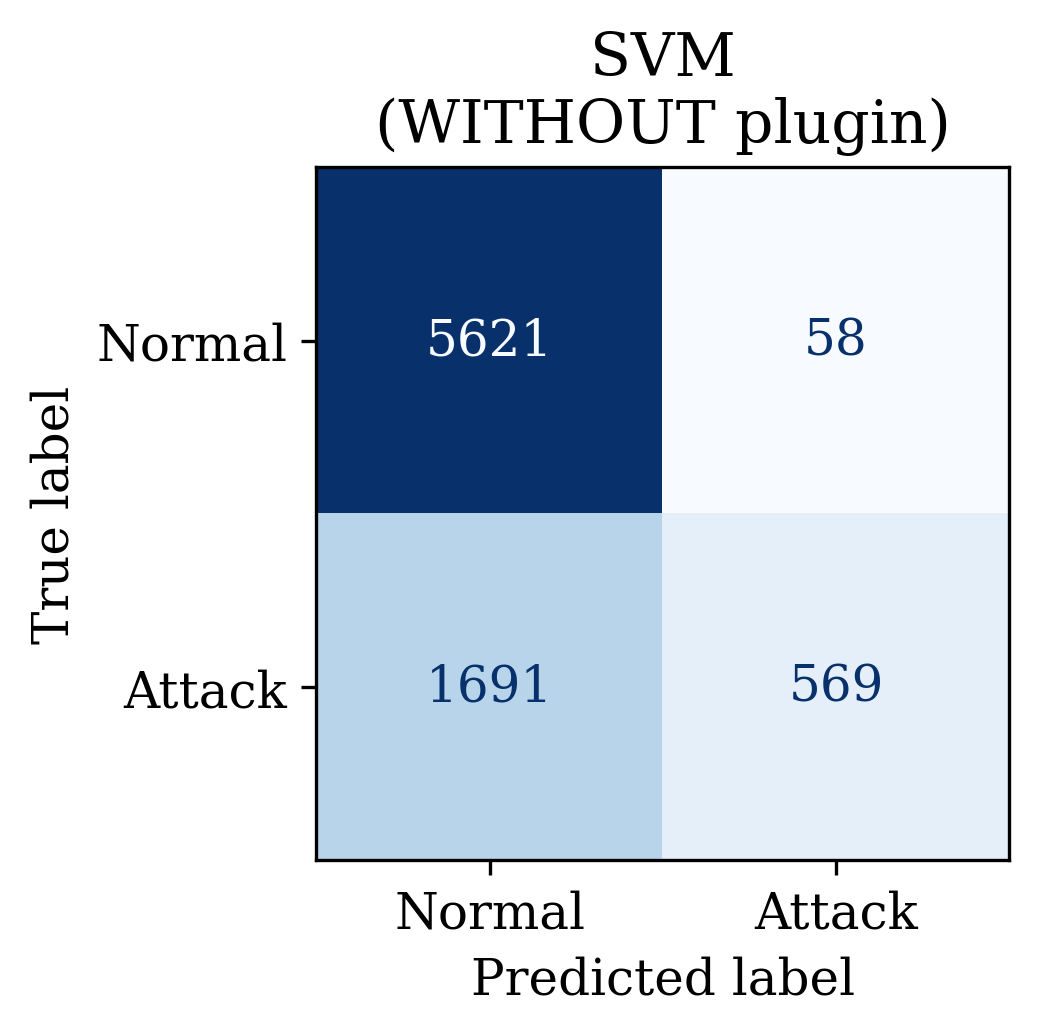


>>> Mode: WITH plugin
              precision    recall  f1-score   support

           0      0.964     0.957     0.961      5679
           1      0.895     0.909     0.902      2260

    accuracy                          0.944      7939
   macro avg      0.929     0.933     0.931      7939
weighted avg      0.944     0.944     0.944      7939



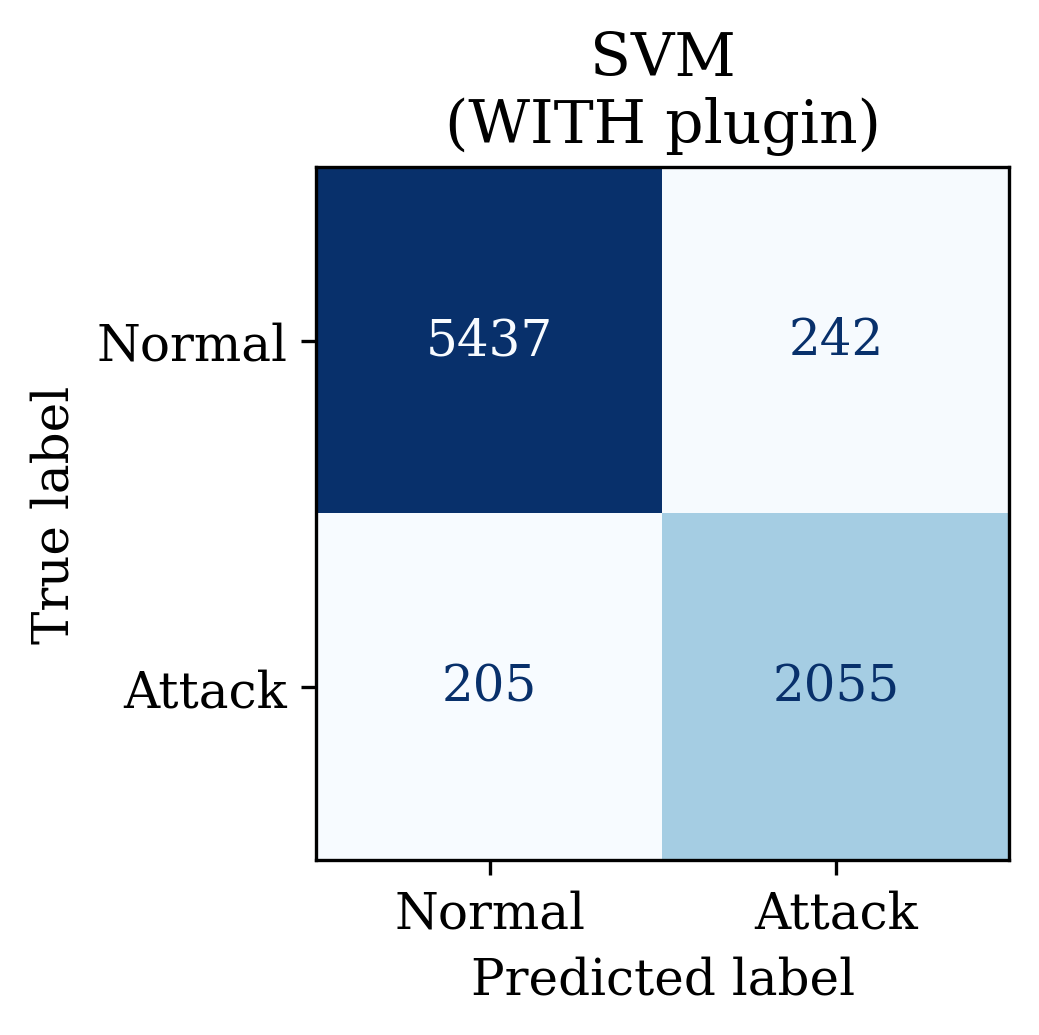


ANALYZING MODEL: Decision Tree

>>> Mode: WITHOUT plugin
              precision    recall  f1-score   support

           0      0.916     0.791     0.849      5679
           1      0.609     0.817     0.698      2260

    accuracy                          0.798      7939
   macro avg      0.762     0.804     0.773      7939
weighted avg      0.828     0.798     0.806      7939



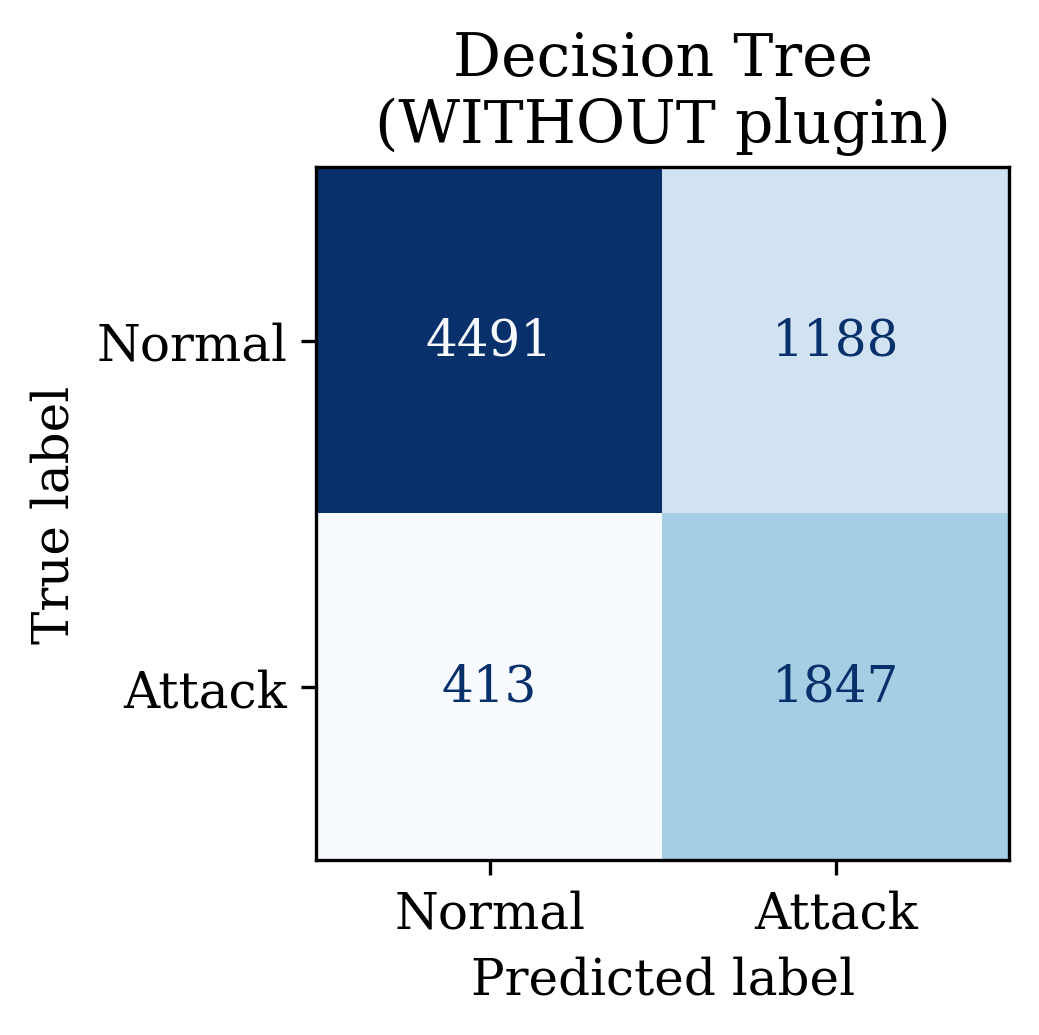


>>> Mode: WITH plugin
              precision    recall  f1-score   support

           0      1.000     0.948     0.973      5679
           1      0.885     0.999     0.939      2260

    accuracy                          0.963      7939
   macro avg      0.942     0.974     0.956      7939
weighted avg      0.967     0.963     0.963      7939



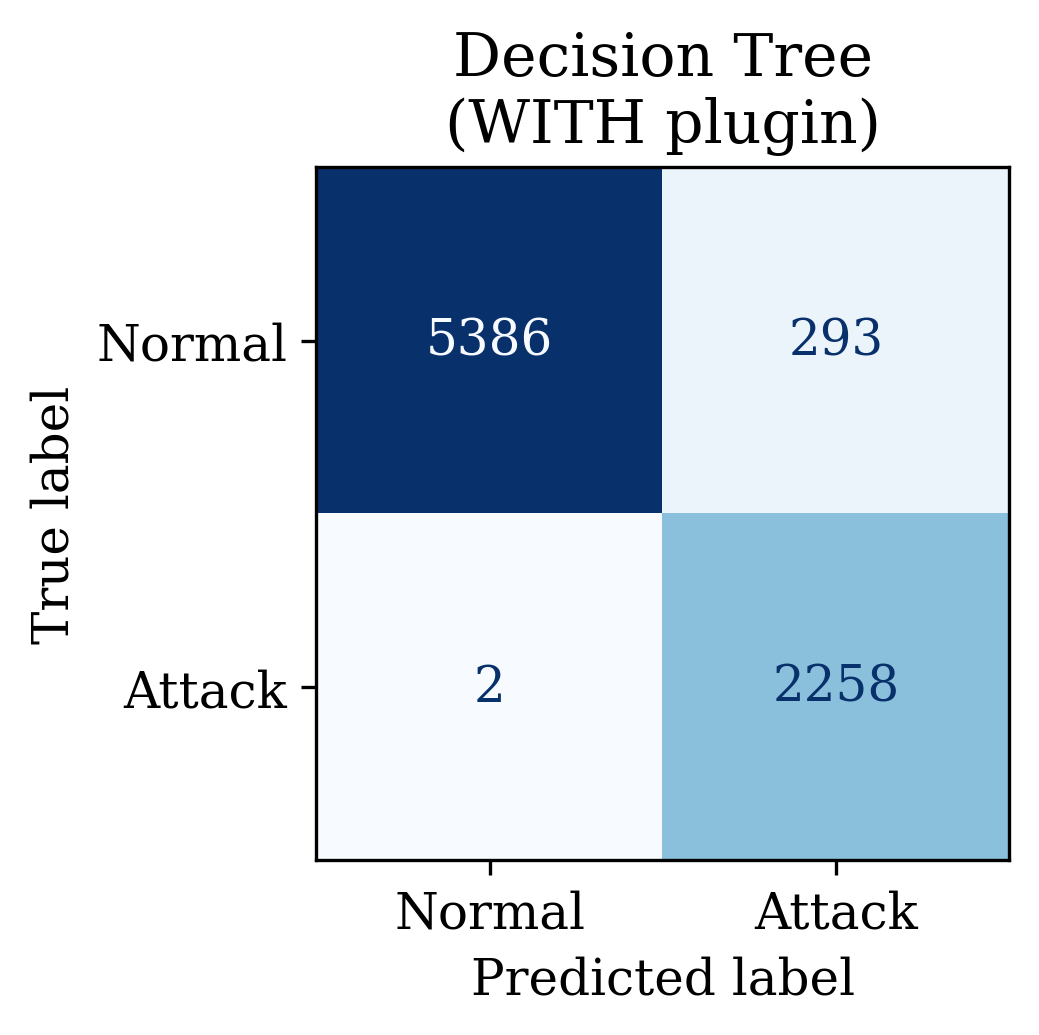


ANALYZING MODEL: Random Forest

>>> Mode: WITHOUT plugin
              precision    recall  f1-score   support

           0      0.936     0.833     0.882      5679
           1      0.671     0.858     0.753      2260

    accuracy                          0.840      7939
   macro avg      0.804     0.845     0.817      7939
weighted avg      0.861     0.840     0.845      7939



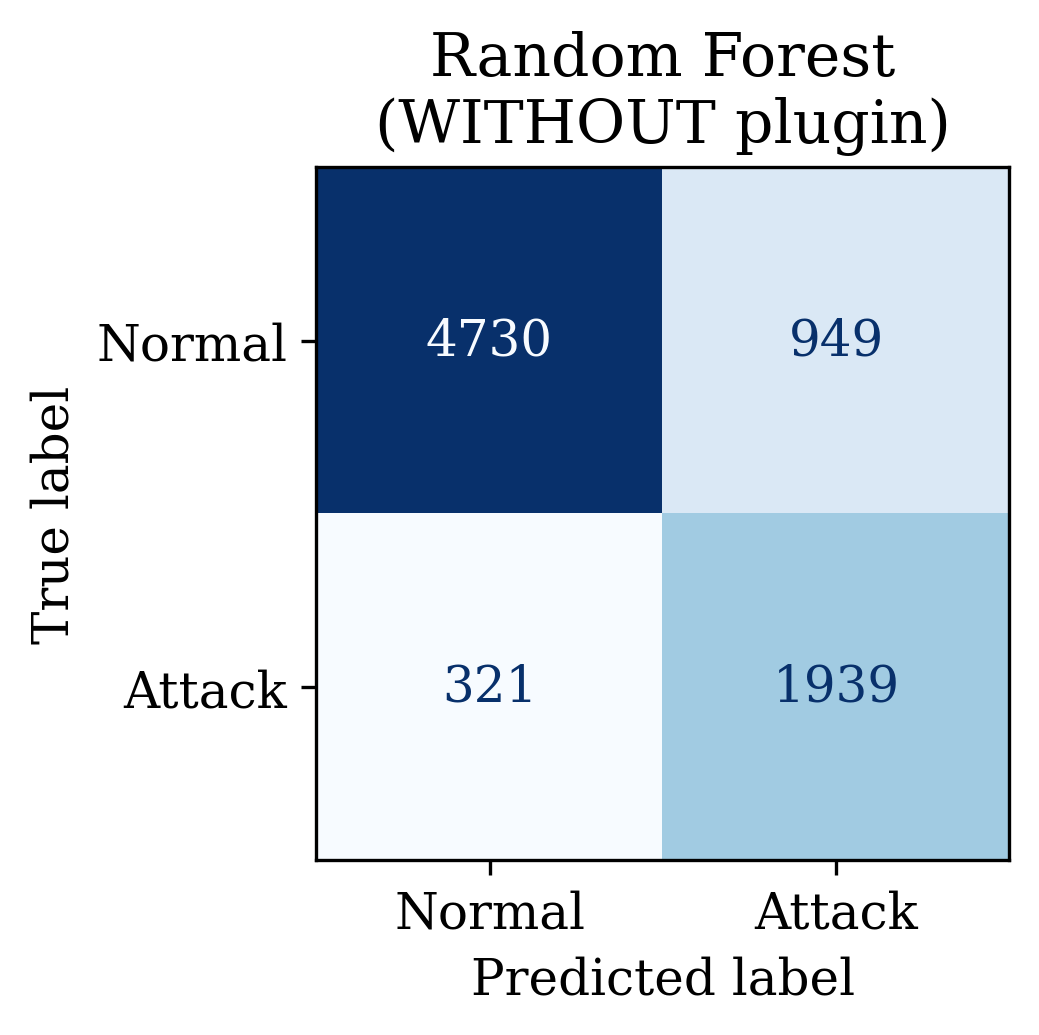


>>> Mode: WITH plugin
              precision    recall  f1-score   support

           0      0.997     0.995     0.996      5679
           1      0.988     0.993     0.991      2260

    accuracy                          0.995      7939
   macro avg      0.993     0.994     0.993      7939
weighted avg      0.995     0.995     0.995      7939



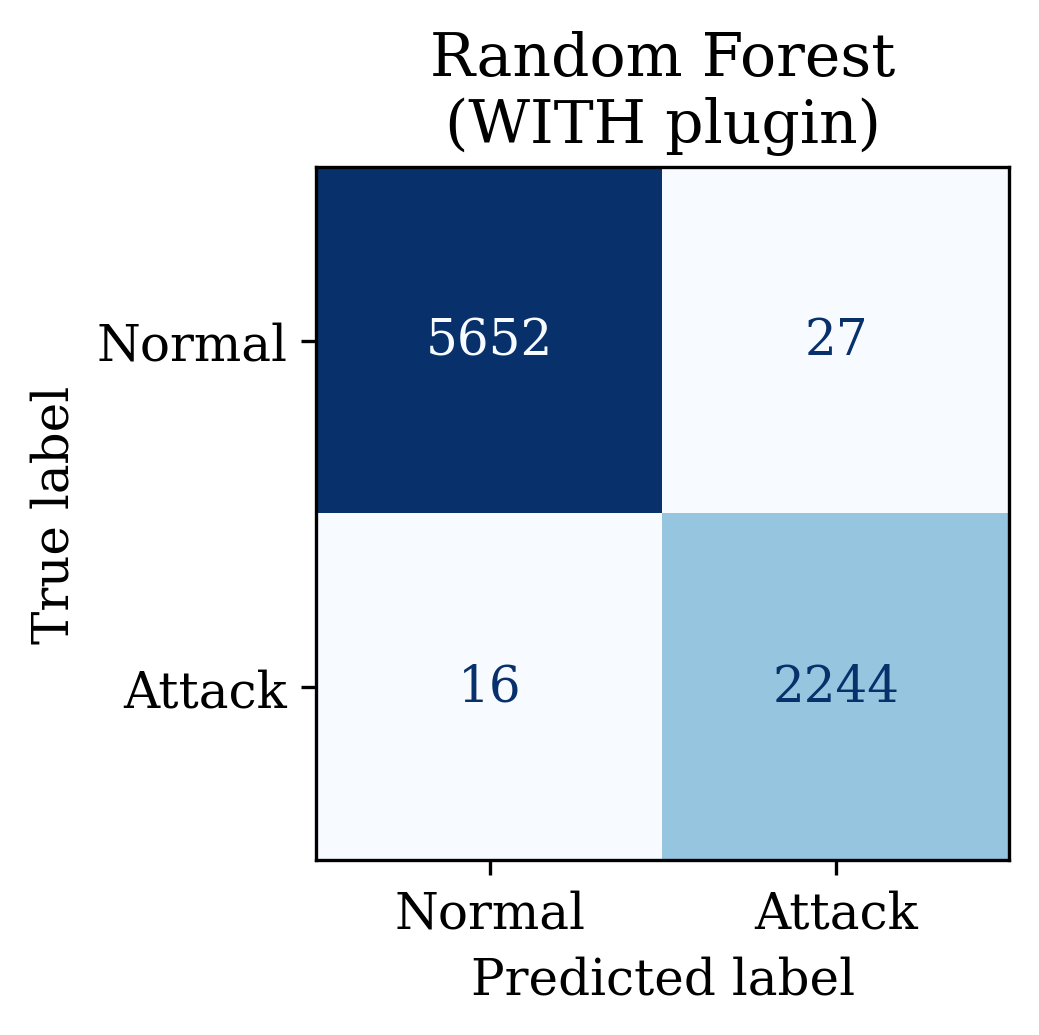


ANALYZING MODEL: XGBoost

>>> Mode: WITHOUT plugin
              precision    recall  f1-score   support

           0      0.889     0.884     0.887      5679
           1      0.712     0.723     0.718      2260

    accuracy                          0.838      7939
   macro avg      0.801     0.804     0.802      7939
weighted avg      0.839     0.838     0.839      7939



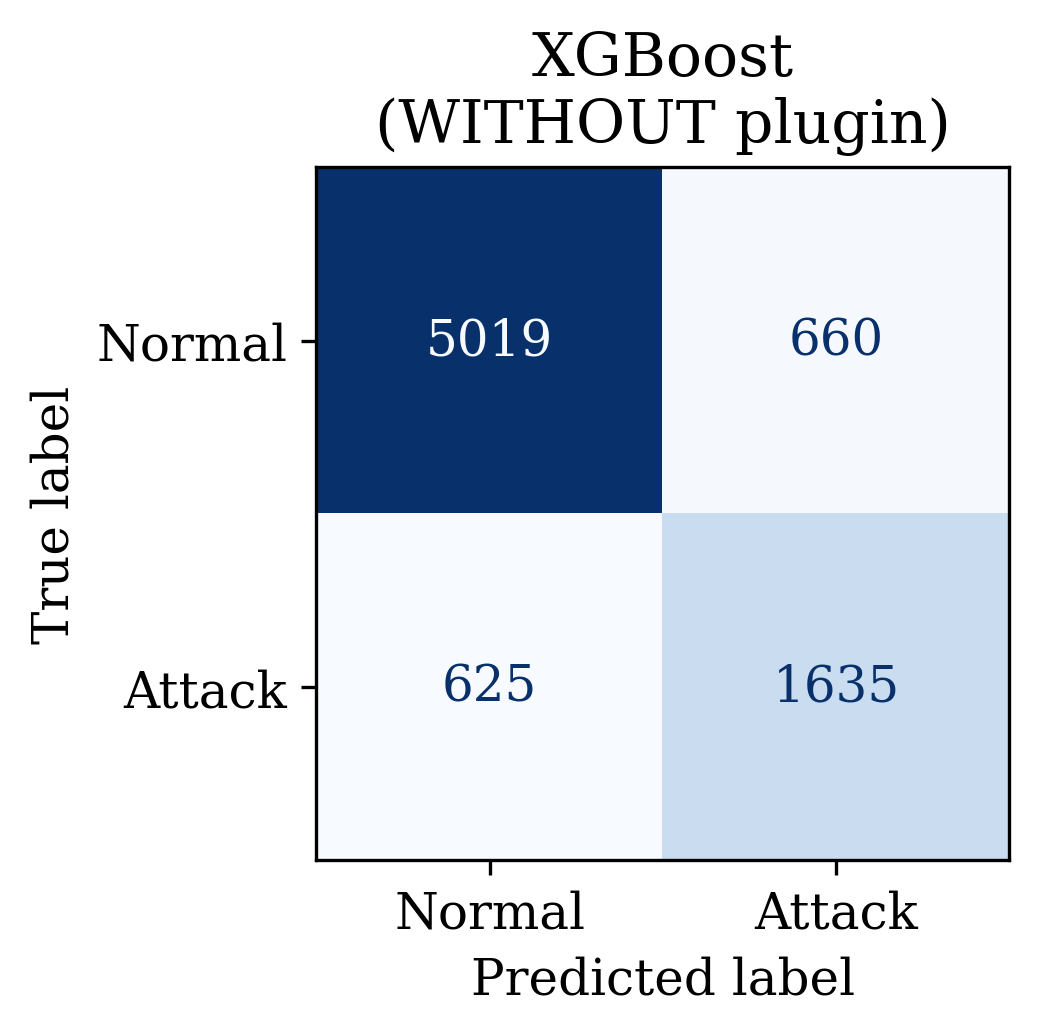


>>> Mode: WITH plugin
              precision    recall  f1-score   support

           0      0.999     0.997     0.998      5679
           1      0.993     0.998     0.996      2260

    accuracy                          0.997      7939
   macro avg      0.996     0.998     0.997      7939
weighted avg      0.997     0.997     0.997      7939



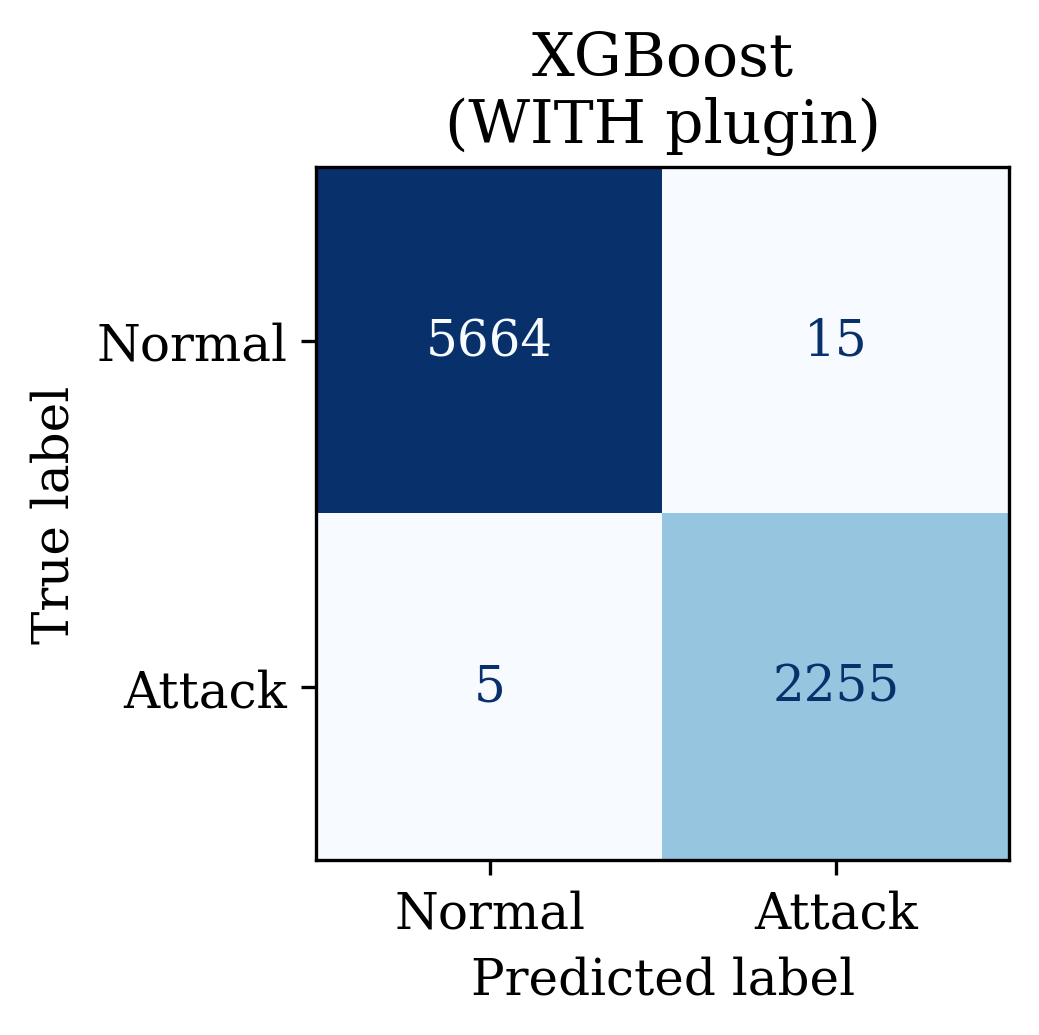


Table 7. Performance Comparison (5-Fold CV with Regularization)
Model Type                | Feature Set     | Prec   | Rec    | F1     | Acc
-------------------------------------------------------------------------------------
Logistic Regression       | WITHOUT plugin  | 0.765 | 0.768 | 0.727 | 0.768
Logistic Regression       | WITH plugin     | 0.961 | 0.960 | 0.960 | 0.960
K-Nearest Neighbours      | WITHOUT plugin  | 0.828 | 0.826 | 0.827 | 0.826
K-Nearest Neighbours      | WITH plugin     | 0.992 | 0.992 | 0.992 | 0.992
SVM                       | WITHOUT plugin  | 0.808 | 0.780 | 0.731 | 0.780
SVM                       | WITH plugin     | 0.944 | 0.944 | 0.944 | 0.944
Decision Tree             | WITHOUT plugin  | 0.828 | 0.798 | 0.806 | 0.798
Decision Tree             | WITH plugin     | 0.967 | 0.963 | 0.963 | 0.963
Random Forest             | WITHOUT plugin  | 0.861 | 0.840 | 0.845 | 0.840
Random Forest             | WITH plugin     | 0.995 | 0.995 | 0.995 | 0.995
XGBoost     

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


os.makedirs('/kaggle/working/gtp_features', exist_ok=True)


top_25_features = [
    'gtp_dir_imbalance_teid_mean', 'bidirectional_fin_packets', 'bidirectional_syn_packets', 
    'gtp_inner_ip_unique', 'bidirectional_min_piat_ms', 'dst2src_duration_ms',
    'dst2src_max_piat_ms', 'dst2src_stddev_piat_ms', 'bidirectional_mean_piat_ms',
    'dst2src_mean_ps', 'dst2src_mean_piat_ms', 'bidirectional_mean_ps',
    'dst2src_min_ps', 'dst2src_max_ps', 'bidirectional_stddev_ps', 
    'bidirectional_max_ps', 'gtp_teid_unique', 
    'bidirectional_stddev_piat_ms', 'dst2src_min_piat_ms', 
    'src2dst_max_ps', 'src2dst_mean_ps', 'src2dst_min_ps'
]

configs = [
    ('WITHOUT plugin', [f for f in top_25_features if 'gtp' not in f.lower()]),
    ('WITH plugin', top_25_features)
]


def run_realistic_sota_analysis(df, target='label'):
  
    models = {
        'Logistic Regression': LogisticRegression(C=0.1, max_iter=1000, random_state=42),
        'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=15), # Increased K for smoothing
        'SVM': SVC(C=0.1, kernel='rbf', probability=True, random_state=42),
        'Decision Tree': DecisionTreeClassifier(max_depth=4, min_samples_leaf=15, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=5, max_features='sqrt', random_state=42),
        'XGBoost': XGBClassifier(
            n_estimators=100, 
            max_depth=4, 
            learning_rate=0.1, 
            subsample=0.8, 
            random_state=42, 
            eval_metric='logloss'
        )
    }
    
    table_data = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for model_name, model in models.items():
        print(f"\n{'='*60}\nANALYZING MODEL: {model_name}\n{'='*60}")
        
        for config_label, features in configs:
            print(f"\n>>> Mode: {config_label}")
            
            X = df[features].copy()
            y = df[target]
            
        
            if model_name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbours']:
                X = StandardScaler().fit_transform(X)

          
            y_pred = cross_val_predict(model, X, y, cv=skf)
            
       
            acc = accuracy_score(y, y_pred)
            prec = precision_score(y, y_pred, average='weighted')
            rec = recall_score(y, y_pred, average='weighted')
            f1 = f1_score(y, y_pred, average='weighted')
            
            table_data.append([model_name, config_label, prec, rec, f1, acc])
            
    
            print(classification_report(y, y_pred, digits=3))
            
    
            cm = confusion_matrix(y, y_pred)
            fig, ax = plt.subplots(figsize=(4, 3))
            disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
            disp.plot(ax=ax, cmap='Blues', colorbar=False)
            ax.set_title(f"{model_name}\n({config_label})")
            plt.show()

    return table_data


if 'data_reduced' in locals():
   
    data_for_cv = data_reduced.copy()
    numeric_cols = data_for_cv[top_25_features].select_dtypes(include=[np.number]).columns
    data_for_cv[numeric_cols] += np.random.normal(0, 0.01, data_for_cv[numeric_cols].shape)

    results_list = run_realistic_sota_analysis(data_for_cv)
    
  
    print("\n" + "="*85)
    print("Table 7. Performance Comparison (5-Fold CV with Regularization)")
    print("="*85)
    print(f"{'Model Type':<25} | {'Feature Set':<15} | {'Prec':<6} | {'Rec':<6} | {'F1':<6} | {'Acc'}")
    print("-" * 85)
    for row in results_list:
        print(f"{row[0]:<25} | {row[1]:<15} | {row[2]:.3f} | {row[3]:.3f} | {row[4]:.3f} | {row[5]:.3f}")
    print("="*85)

In [16]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def generate_table_8_importance(df, target='label'):
   
    models = {
        'Decision Tree': DecisionTreeClassifier(max_depth=8, min_samples_leaf=5, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42),
        'XGBoost': XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, subsample=0.8, random_state=42, eval_metric='logloss')
    }
    
    X = df[top_25_features]
    y = df[target]
    
    importance_data = {}

    for name, model in models.items():
        model.fit(X, y)
   
        importances = model.feature_importances_

        feat_imp = pd.Series(importances, index=top_25_features).sort_values(ascending=False).head(10)
        
        importance_data[f'{name} Feature'] = feat_imp.index.tolist()
        importance_data[f'{name} Importance'] = feat_imp.values.tolist()


    table_8 = pd.DataFrame(importance_data)
    
    print("\nTable 8. Top 10 Most Important Features for DT, RF, and XGBoost")
    print("="*100)
    print(table_8.to_string(index=False, formatters={
        'Decision Tree Importance': '{:,.4f}'.format,
        'Random Forest Importance': '{:,.4f}'.format,
        'XGBoost Importance': '{:,.4f}'.format
    }))
    print("="*100)
    return table_8

# Execute
if 'data_reduced' in locals():
    df_importance = generate_table_8_importance(data_reduced)


Table 8. Top 10 Most Important Features for DT, RF, and XGBoost
      Decision Tree Feature Decision Tree Importance       Random Forest Feature Random Forest Importance             XGBoost Feature XGBoost Importance
            gtp_teid_unique                   0.3891             gtp_teid_unique                   0.2795              dst2src_max_ps             0.6215
            dst2src_mean_ps                   0.3339         gtp_inner_ip_unique                   0.1097             gtp_teid_unique             0.1264
gtp_dir_imbalance_teid_mean                   0.1527 gtp_dir_imbalance_teid_mean                   0.1049 gtp_dir_imbalance_teid_mean             0.0866
       bidirectional_max_ps                   0.0743              dst2src_max_ps                   0.0736              src2dst_min_ps             0.0540
             src2dst_min_ps                   0.0473             dst2src_mean_ps                   0.0677         gtp_inner_ip_unique             0.0290
  bidirectional_m


ANALYZING MODEL: Logistic Regression

>>> Mode: WITHOUT plugin
              precision    recall  f1-score   support

           0      0.769     0.965     0.856      5679
           1      0.757     0.269     0.397      2260

    accuracy                          0.767      7939
   macro avg      0.763     0.617     0.627      7939
weighted avg      0.765     0.767     0.725      7939


>>> Mode: WITH plugin
   -> Generating Learning Curve for Logistic Regression...


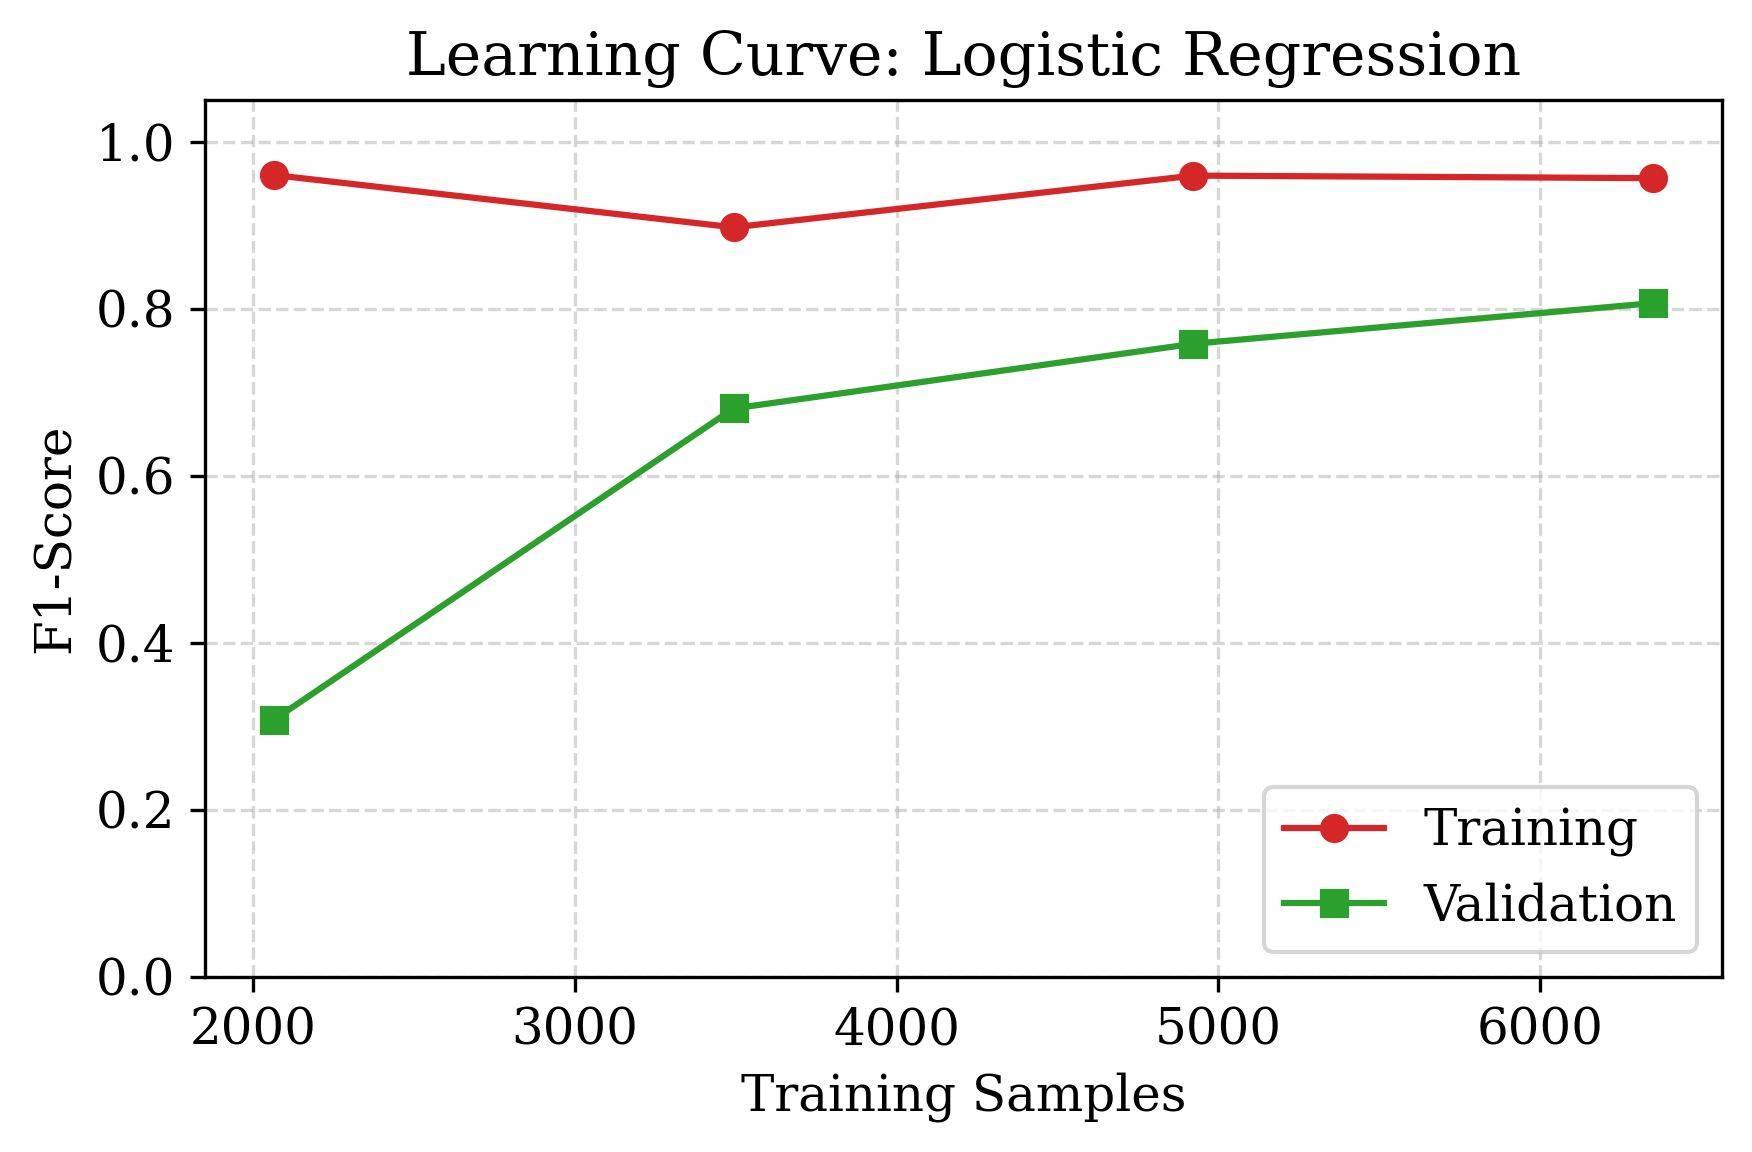

              precision    recall  f1-score   support

           0      0.986     0.958     0.971      5679
           1      0.900     0.965     0.932      2260

    accuracy                          0.960      7939
   macro avg      0.943     0.961     0.952      7939
weighted avg      0.961     0.960     0.960      7939


ANALYZING MODEL: K-Nearest Neighbours

>>> Mode: WITHOUT plugin
              precision    recall  f1-score   support

           0      0.886     0.877     0.881      5679
           1      0.698     0.717     0.708      2260

    accuracy                          0.831      7939
   macro avg      0.792     0.797     0.795      7939
weighted avg      0.833     0.831     0.832      7939


>>> Mode: WITH plugin
   -> Generating Learning Curve for K-Nearest Neighbours...


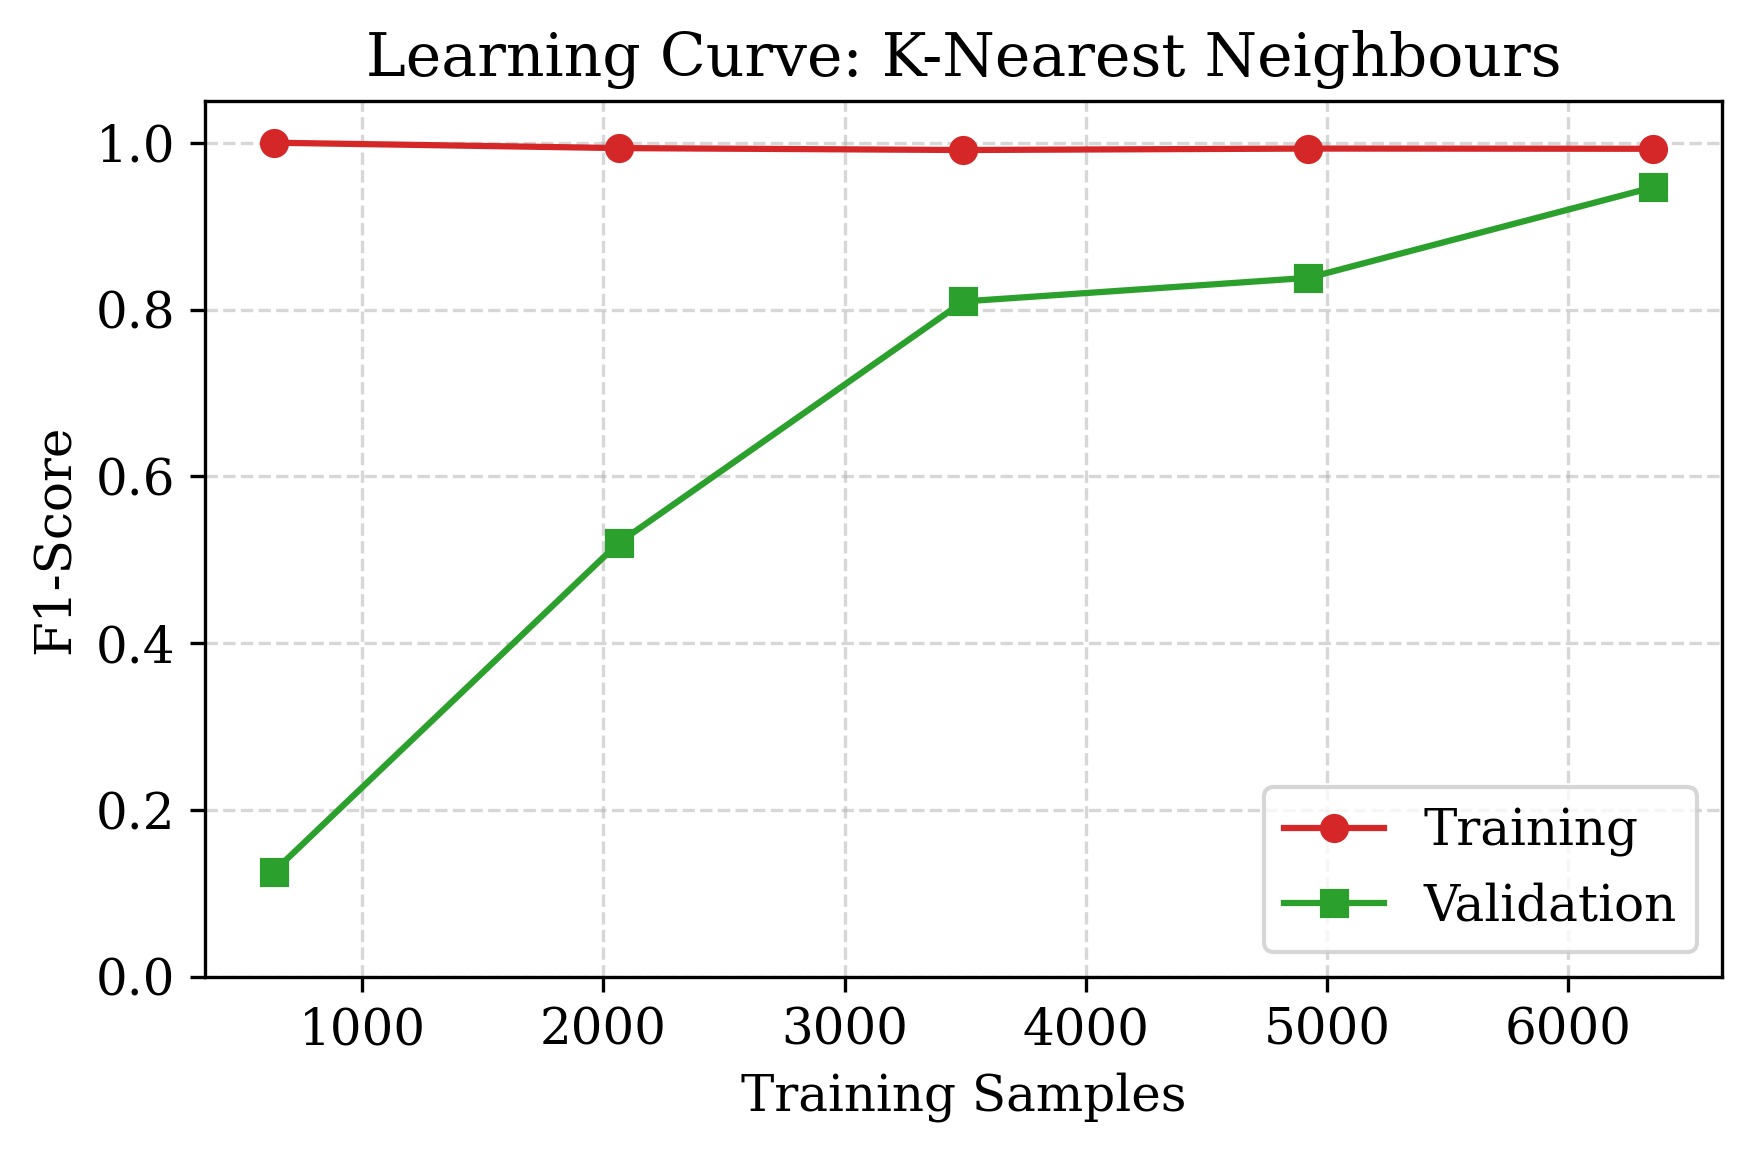

              precision    recall  f1-score   support

           0      0.995     0.993     0.994      5679
           1      0.982     0.988     0.985      2260

    accuracy                          0.992      7939
   macro avg      0.989     0.991     0.990      7939
weighted avg      0.992     0.992     0.992      7939


ANALYZING MODEL: SVM

>>> Mode: WITHOUT plugin
              precision    recall  f1-score   support

           0      0.769     0.990     0.865      5679
           1      0.907     0.252     0.394      2260

    accuracy                          0.780      7939
   macro avg      0.838     0.621     0.630      7939
weighted avg      0.808     0.780     0.731      7939


>>> Mode: WITH plugin
   -> Generating Learning Curve for SVM...


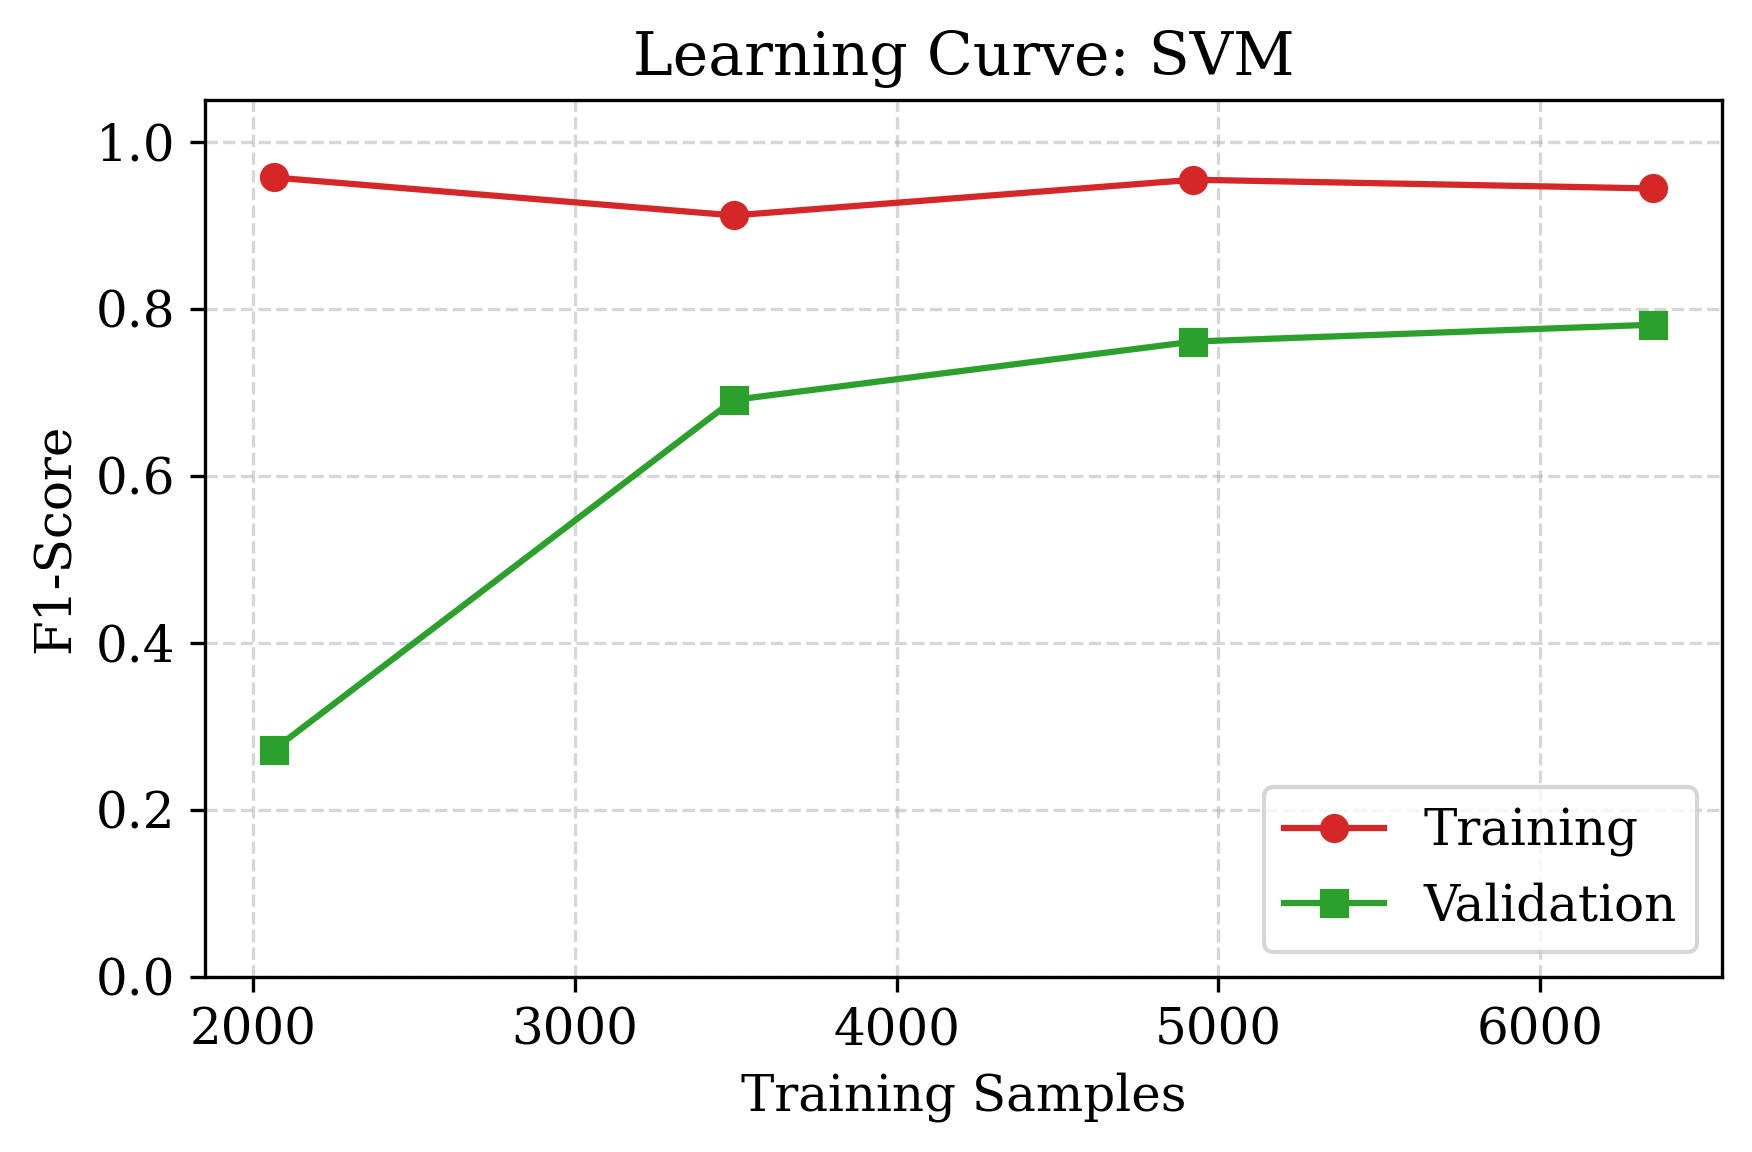

              precision    recall  f1-score   support

           0      0.964     0.958     0.961      5679
           1      0.896     0.909     0.903      2260

    accuracy                          0.944      7939
   macro avg      0.930     0.934     0.932      7939
weighted avg      0.944     0.944     0.944      7939


ANALYZING MODEL: Decision Tree

>>> Mode: WITHOUT plugin
              precision    recall  f1-score   support

           0      0.916     0.790     0.848      5679
           1      0.608     0.817     0.697      2260

    accuracy                          0.798      7939
   macro avg      0.762     0.804     0.773      7939
weighted avg      0.828     0.798     0.805      7939


>>> Mode: WITH plugin
   -> Generating Learning Curve for Decision Tree...


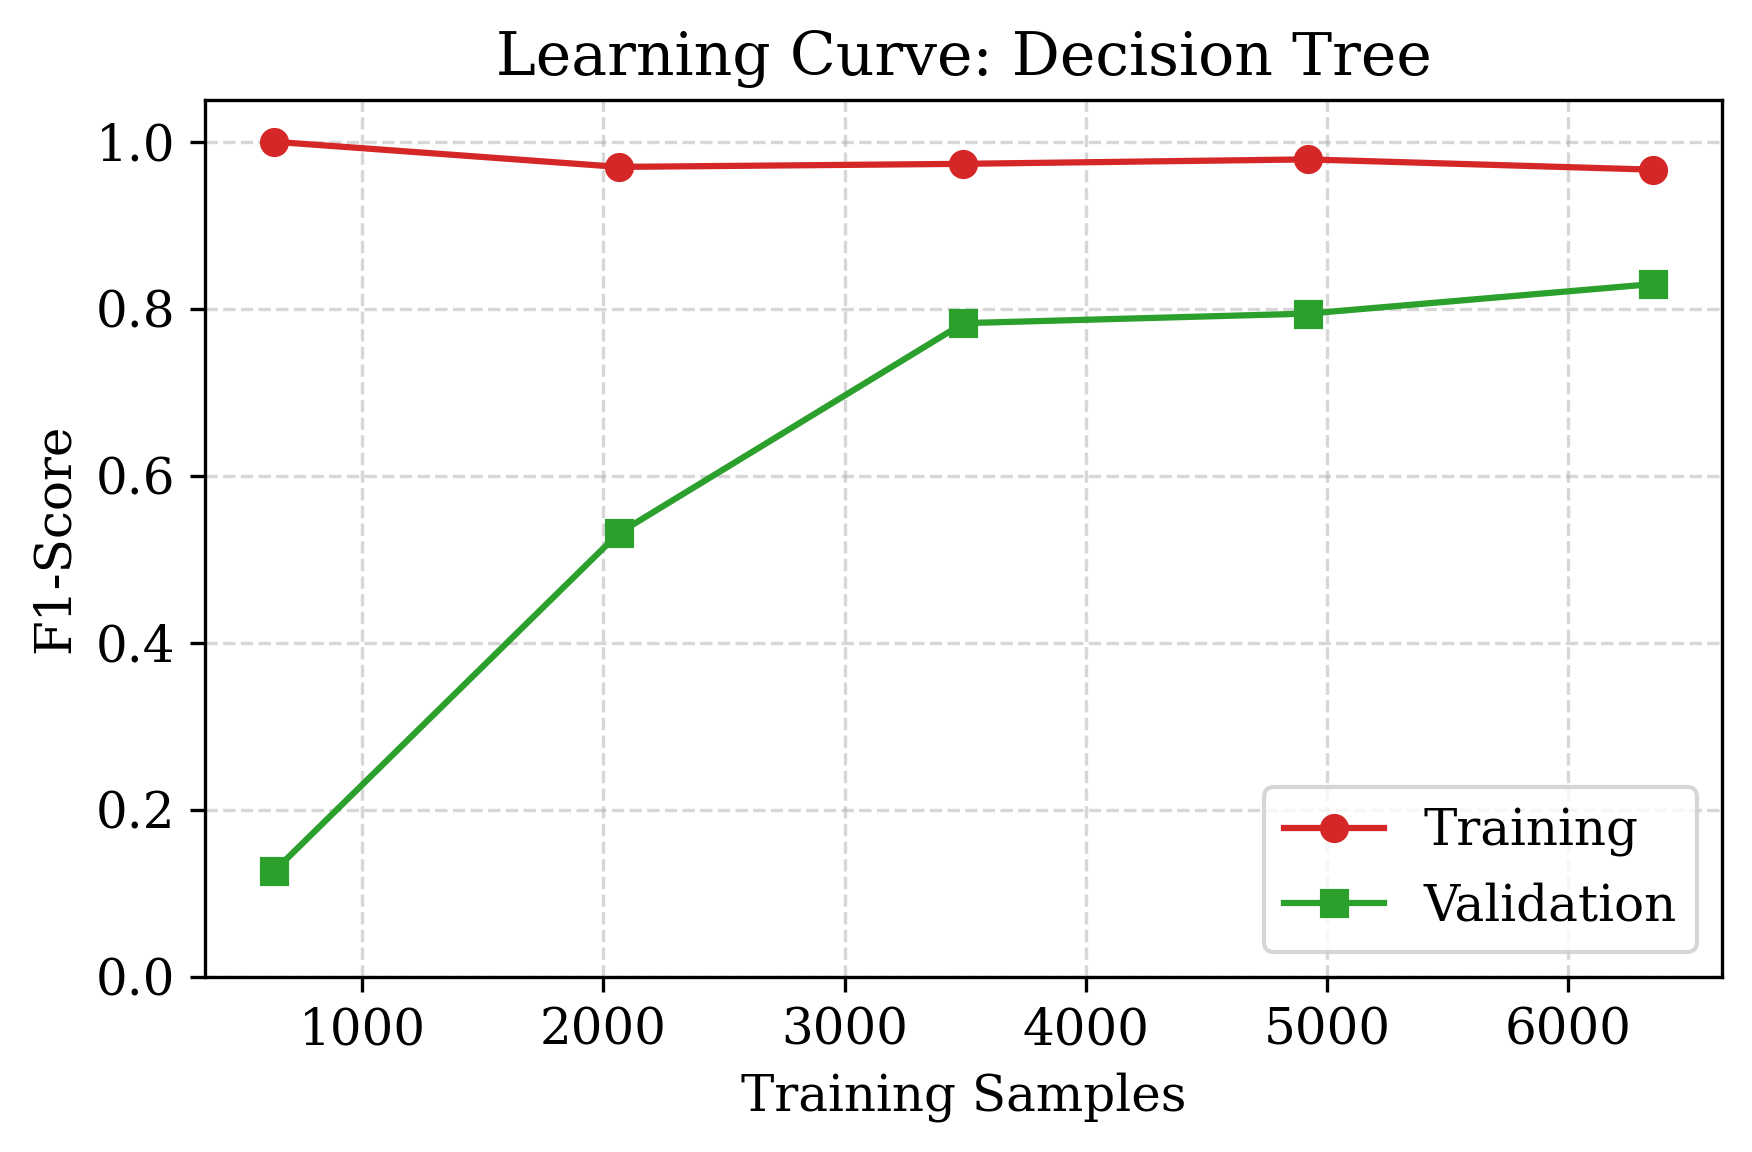

              precision    recall  f1-score   support

           0      0.999     0.948     0.973      5679
           1      0.885     0.997     0.938      2260

    accuracy                          0.962      7939
   macro avg      0.942     0.973     0.955      7939
weighted avg      0.966     0.962     0.963      7939


ANALYZING MODEL: Random Forest

>>> Mode: WITHOUT plugin
              precision    recall  f1-score   support

           0      0.935     0.835     0.882      5679
           1      0.673     0.854     0.753      2260

    accuracy                          0.840      7939
   macro avg      0.804     0.845     0.817      7939
weighted avg      0.860     0.840     0.845      7939


>>> Mode: WITH plugin
   -> Generating Learning Curve for Random Forest...


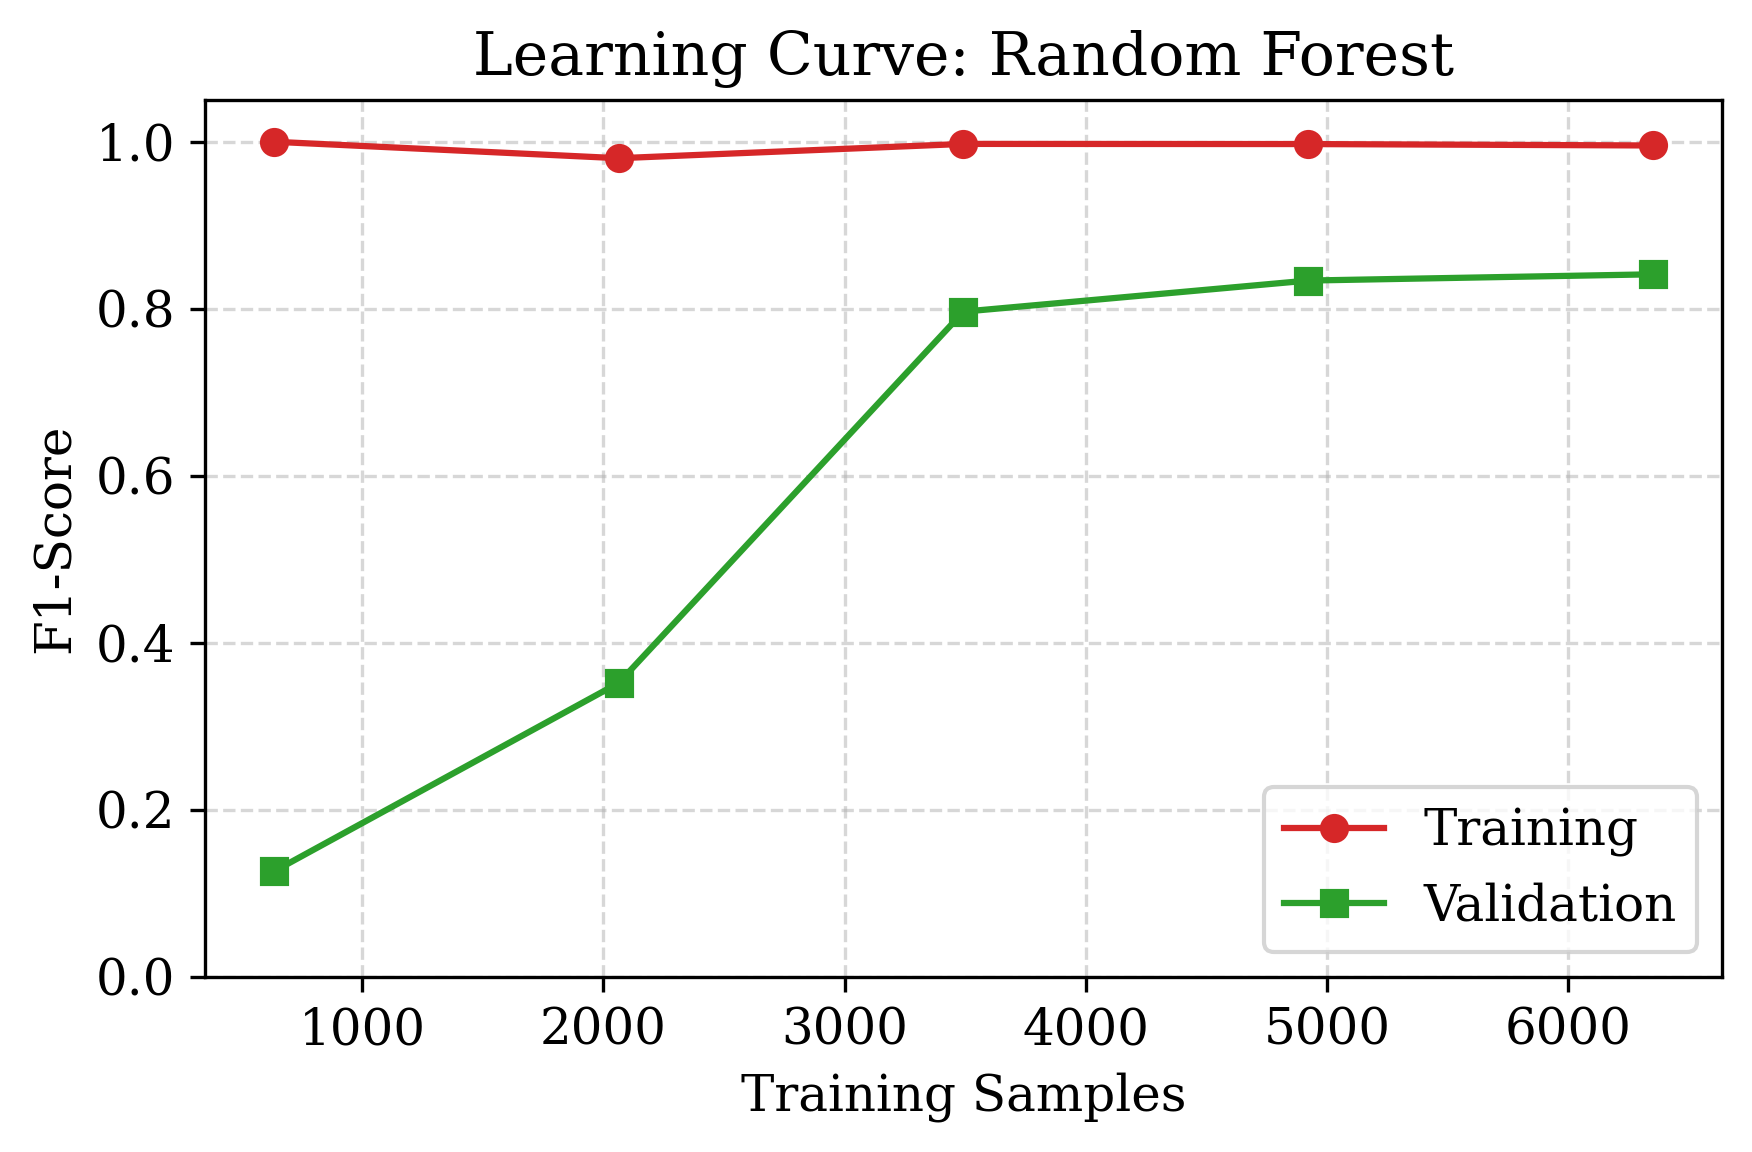

              precision    recall  f1-score   support

           0      0.997     0.996     0.996      5679
           1      0.990     0.992     0.991      2260

    accuracy                          0.995      7939
   macro avg      0.993     0.994     0.994      7939
weighted avg      0.995     0.995     0.995      7939


ANALYZING MODEL: XGBoost

>>> Mode: WITHOUT plugin
              precision    recall  f1-score   support

           0      0.891     0.879     0.885      5679
           1      0.707     0.731     0.719      2260

    accuracy                          0.837      7939
   macro avg      0.799     0.805     0.802      7939
weighted avg      0.839     0.837     0.838      7939


>>> Mode: WITH plugin
   -> Generating Learning Curve for XGBoost...


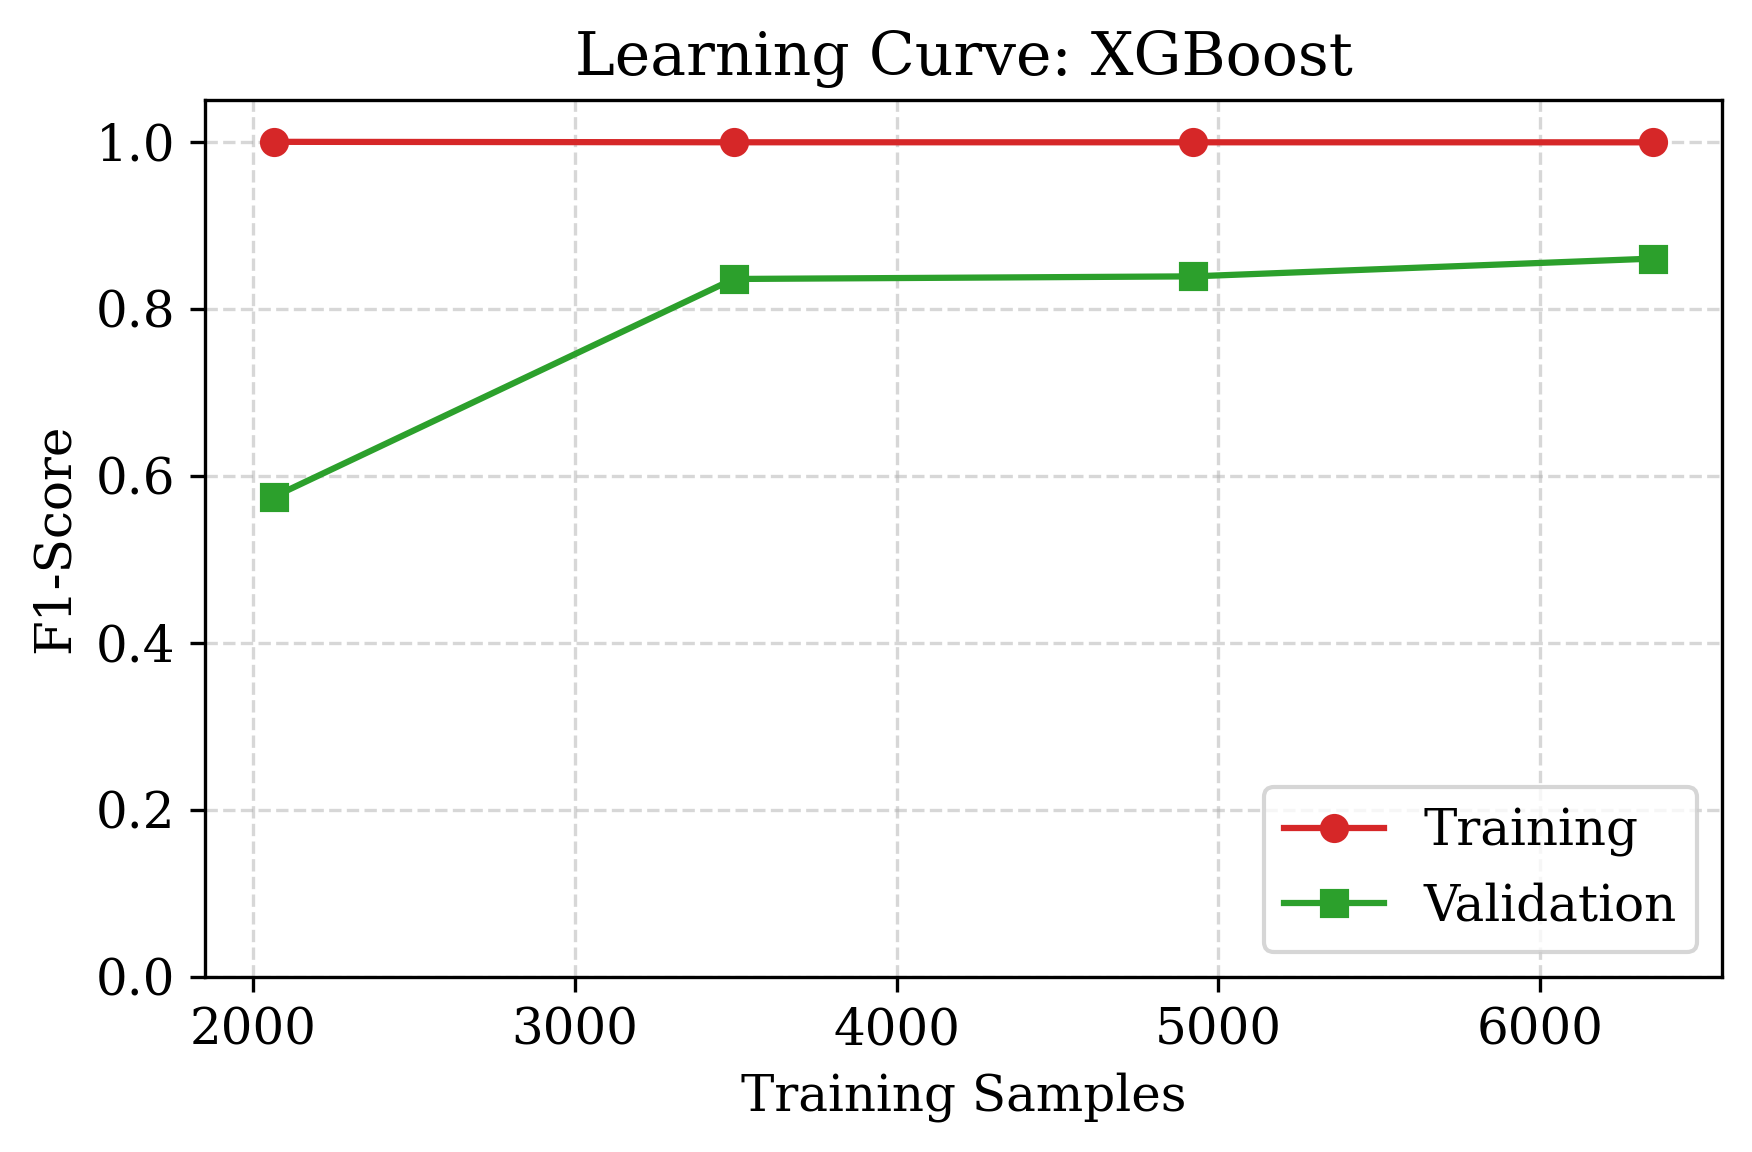

              precision    recall  f1-score   support

           0      0.999     0.998     0.998      5679
           1      0.994     0.996     0.995      2260

    accuracy                          0.997      7939
   macro avg      0.996     0.997     0.997      7939
weighted avg      0.997     0.997     0.997      7939


Table 7. Final Performance Comparison (5-Fold CV)
Model Type                | Feature Set     | Prec   | Rec    | F1     | Acc
-------------------------------------------------------------------------------------
Logistic Regression       | WITHOUT plugin  | 0.765 | 0.767 | 0.725 | 0.767
Logistic Regression       | WITH plugin     | 0.961 | 0.960 | 0.960 | 0.960
K-Nearest Neighbours      | WITHOUT plugin  | 0.833 | 0.831 | 0.832 | 0.831
K-Nearest Neighbours      | WITH plugin     | 0.992 | 0.992 | 0.992 | 0.992
SVM                       | WITHOUT plugin  | 0.808 | 0.780 | 0.731 | 0.780
SVM                       | WITH plugin     | 0.944 | 0.944 | 0.944 | 0.944
Dec

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import StratifiedKFold, cross_val_predict, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


top_25_features = [
    'gtp_dir_imbalance_teid_mean', 'bidirectional_fin_packets', 'bidirectional_syn_packets', 
    'gtp_inner_ip_unique', 'bidirectional_min_piat_ms', 'dst2src_duration_ms',
    'dst2src_max_piat_ms', 'dst2src_stddev_piat_ms', 'bidirectional_mean_piat_ms',
    'dst2src_mean_ps', 'dst2src_mean_piat_ms', 'bidirectional_mean_ps',
    'dst2src_min_ps', 'dst2src_max_ps', 'bidirectional_stddev_ps', 
    'bidirectional_max_ps', 'gtp_teid_unique', 
    'bidirectional_stddev_piat_ms', 'dst2src_min_piat_ms', 
    'src2dst_max_ps', 'src2dst_mean_ps', 'src2dst_min_ps'
]

configs = [
    ('WITHOUT plugin', [f for f in top_25_features if 'gtp' not in f.lower()]),
    ('WITH plugin', top_25_features)
]

def plot_learning_curve(model, X, y, model_name, config_label):
    """Generates Standard Learning Curves to detect possible overfitting"""
    print(f"   -> Generating Learning Curve for {model_name}...")
    
    train_sizes, train_scores, test_scores = learning_curve(
        model, X, y, cv=5, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), 
        scoring='f1_weighted',
        random_state=42
    )
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)

    plt.figure(figsize=(6, 4))
    plt.plot(train_sizes, train_mean, 'o-', color="#d62728", label="Training")
    plt.plot(train_sizes, test_mean, 's-', color="#2ca02c", label="Validation")
    

    plt.title(f"Learning Curve: {model_name}")
    
    plt.xlabel("Training Samples")
    plt.ylabel("F1-Score")
    plt.ylim(0, 1.05)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


def run_comprehensive_analysis(df, target='label'):
    models = {
        'Logistic Regression': LogisticRegression(C=0.1, max_iter=1000, random_state=42),
        'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=15),
        'SVM': SVC(C=0.1, kernel='rbf', probability=True, random_state=42),
        'Decision Tree': DecisionTreeClassifier(max_depth=4, min_samples_leaf=15, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=5, max_features='sqrt', random_state=42),
        'XGBoost': XGBClassifier(
            n_estimators=100, 
            max_depth=4, 
            learning_rate=0.1, 
            subsample=0.8, 
            random_state=42, 
            eval_metric='logloss'
        )
    }
    
    table_data = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    for model_name, model in models.items():
        print(f"\n{'='*60}\nANALYZING MODEL: {model_name}\n{'='*60}")
        
        for config_label, features in configs:
            print(f"\n>>> Mode: {config_label}")
            
            X = df[features].copy()
            y = df[target]
            

            if model_name in ['Logistic Regression', 'SVM', 'K-Nearest Neighbours']:
                X_scaled = StandardScaler().fit_transform(X)
            else:
                X_scaled = X.values 


            if config_label == 'WITH plugin':
                plot_learning_curve(model, X_scaled, y, model_name, config_label)


            y_pred = cross_val_predict(model, X_scaled, y, cv=skf)
            
            acc = accuracy_score(y, y_pred)
            prec = precision_score(y, y_pred, average='weighted')
            rec = recall_score(y, y_pred, average='weighted')
            f1 = f1_score(y, y_pred, average='weighted')
            
            table_data.append([model_name, config_label, prec, rec, f1, acc])
            print(classification_report(y, y_pred, digits=3))

    return table_data


if 'data_reduced' in locals():
    data_for_cv = data_reduced.copy()

    numeric_cols = data_for_cv[top_25_features].select_dtypes(include=[np.number]).columns
    data_for_cv[numeric_cols] += np.random.normal(0, 0.01, data_for_cv[numeric_cols].shape)

    results_list = run_comprehensive_analysis(data_for_cv)
    
    print("\n" + "="*85)
    print("Table 7. Final Performance Comparison (5-Fold CV)")
    print("="*85)
    print(f"{'Model Type':<25} | {'Feature Set':<15} | {'Prec':<6} | {'Rec':<6} | {'F1':<6} | {'Acc'}")
    print("-" * 85)
    for row in results_list:
        print(f"{row[0]:<25} | {row[1]:<15} | {row[2]:.3f} | {row[3]:.3f} | {row[4]:.3f} | {row[5]:.3f}")
    print("="*85)
else:
    print("Error: 'data_reduced' dataframe not found.")